# Parameter Sweep: Poisson VAE vs GumbelSoftmaxPoisson VAE

This notebook manages a comprehensive parameter sweep comparing:
- **Poisson VAE** (Thinned Point Process)
- **GumbelSoftmaxPoisson VAE** (Categorical Softmax Approximation)

## Sweep Parameters
| Parameter | Values |
|-----------|--------|
| Distribution | `poisson`, `gumbel` |
| Temperature | 0.01, 0.1, 0.4 |
| Annealing | True, False |
| N_EXP/N_CUTOFF | 16, 64, 256 |
| Seeds | 0, 1, 2 |

**Total Configurations:** 108 (54 per distribution type)

## Step 1: Initialize Job Queue

Run this cell once to create the job queue with all 108 configurations.

In [ ]:
!.venv/bin/python scripts/gpu_sweep_manager.py --init

## Step 2: Start GPU Workers in tmux

Run these commands in a terminal to start 4 GPU workers and a monitoring session:

```bash
# Start a new tmux session
tmux new-session -d -s sweep

# Create 4 GPU worker windows
tmux new-window -t sweep -n gpu0 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 0'
tmux new-window -t sweep -n gpu1 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 1'
tmux new-window -t sweep -n gpu2 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 2'
tmux new-window -t sweep -n gpu3 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 3'

# Create monitoring window
tmux new-window -t sweep -n monitor 'cd /home/michael/code/poisson_notebook && watch -n 10 .venv/bin/python scripts/monitor_sweep.py'

# Attach to the session
tmux attach -t sweep
```

**Or run all at once (copy-paste this block):**

In [ ]:
# Copy this entire block and paste in terminal to start the sweep
tmux_commands = """
tmux new-session -d -s sweep
tmux new-window -t sweep -n gpu0 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 0'
tmux new-window -t sweep -n gpu1 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 1'
tmux new-window -t sweep -n gpu2 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 2'
tmux new-window -t sweep -n gpu3 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 3'
tmux new-window -t sweep -n monitor 'cd /home/michael/code/poisson_notebook && watch -n 10 .venv/bin/python scripts/monitor_sweep.py'
tmux attach -t sweep
""".strip()

print("Copy and paste the following commands in your terminal:\n")
print(tmux_commands)

## Step 3: Monitor Progress

You can check progress from this notebook while training runs:

In [1]:
import json
from pathlib import Path
from datetime import datetime

def check_sweep_progress():
    """Check current sweep progress."""
    queue_file = Path('./checkpoints/sweep/job_queue.json')
    
    if not queue_file.exists():
        print("No sweep initialized. Run Step 1 first.")
        return
    
    with open(queue_file, 'r') as f:
        data = json.load(f)
    
    jobs = data['jobs']
    
    status_counts = {'pending': 0, 'running': 0, 'completed': 0, 'failed': 0}
    running_jobs = []
    
    for job in jobs:
        if job['status'] == 'pending':
            status_counts['pending'] += 1
        elif job['status'].startswith('running'):
            status_counts['running'] += 1
            running_jobs.append(job)
        elif job['status'] == 'completed':
            status_counts['completed'] += 1
        elif job['status'] == 'failed':
            status_counts['failed'] += 1
    
    total = len(jobs)
    pct = (status_counts['completed'] / total) * 100 if total > 0 else 0
    
    print(f"{'='*60}")
    print(f"  SWEEP PROGRESS - {datetime.now().strftime('%H:%M:%S')}")
    print(f"{'='*60}")
    print(f"  Completed: {status_counts['completed']:3d}/{total} ({pct:.1f}%)")
    print(f"  Running:   {status_counts['running']:3d}")
    print(f"  Pending:   {status_counts['pending']:3d}")
    print(f"  Failed:    {status_counts['failed']:3d}")
    print()
    
    if running_jobs:
        print("  Currently Running:")
        for job in running_jobs:
            name = f"{job['dist_type']}_temp{job['temp']}_anneal{job['anneal']}_n{job['n_param']}_seed{job['seed']}"
            gpu = job.get('gpu', '?')
            print(f"    GPU {gpu}: {name}")

check_sweep_progress()

  SWEEP PROGRESS - 20:35:55
  Completed: 108/108 (100.0%)
  Running:     0
  Pending:     0
  Failed:      0



---
## Step 4: Analyze Results (After Sweep Completes)

Load all completed experiments and visualize results.

In [2]:
import json
import numpy as np
from pathlib import Path

def load_sweep_results():
    """Load all sweep results into a DataFrame."""
    import pandas as pd  # Import here to avoid circular import issues
    
    sweep_dir = Path('./checkpoints/sweep')
    results = []
    
    for model_dir in sweep_dir.iterdir():
        if not model_dir.is_dir() or model_dir.name.startswith('.'):
            continue
        
        metrics_file = model_dir / 'metrics.json'
        config_file = model_dir / 'sweep_config.json'
        
        if not metrics_file.exists():
            continue
        
        with open(metrics_file, 'r') as f:
            metrics = json.load(f)
        
        if config_file.exists():
            with open(config_file, 'r') as f:
                config = json.load(f)
        else:
            # Parse config from directory name
            parts = model_dir.name.split('_')
            config = {
                'dist_type': parts[0],
                'temp': float(parts[1].replace('temp', '')),
                'anneal': parts[2].replace('anneal', '') == 'True',
                'n_param': int(parts[3].replace('n', '')),
                'seed': int(parts[4].replace('seed', '')),
            }
        
        results.append({
            **config,
            **metrics,
            'model_dir': str(model_dir),
        })
    
    if not results:
        print("No completed experiments found.")
        return None
    
    df = pd.DataFrame(results)
    print(f"Loaded {len(df)} experiments")
    return df

df = load_sweep_results()
if df is not None:
    display(df.head(10))

Loaded 108 experiments


,dist_type,temp,anneal,n_param,seed,epochs,status,gpu,start_time,config,total_time,n_params,neg_elbo,recon_loss,kl_loss,n_active,lifetime_sparsity,kl_per_dim,model_dir,eval_temp
0,gumbel,0.10,False,15,0,2000,running_gpu1,1,1.767570e+09,"{'dist_type': 'gumbel', 'temp': 0.1, 'anneal':...",2407.300987,262656,178.426666,141.772690,36.653973,494,0.416842,"[0.08075112104415894, 0.0498814694583416, 0.02...",checkpoints/sweep/gumbel_temp0.1_annealFalse_n...,NaN
1,gumbel,0.10,True,10,0,2000,running_gpu1,1,1.767563e+09,"{'dist_type': 'gumbel', 'temp': 0.1, 'anneal':...",2435.726448,262656,178.114990,141.497818,36.617172,512,0.414150,"[0.1152099147439003, 0.08627834916114807, 0.01...",checkpoints/sweep/gumbel_temp0.1_annealTrue_n1...,NaN
2,gumbel,0.40,False,15,1,2000,running_gpu0,0,1.767582e+09,"{'dist_type': 'gumbel', 'temp': 0.4, 'anneal':...",2371.248435,262656,183.593994,145.098038,38.495964,512,0.405805,"[0.1616271436214447, 0.15656225383281708, 0.01...",checkpoints/sweep/gumbel_temp0.4_annealFalse_n...,NaN
3,gumbel,0.01,True,15,1,2000,running_gpu3,3,1.767553e+09,"{'dist_type': 'gumbel', 'temp': 0.01, 'anneal'...",2440.074494,262656,179.036865,143.774292,35.262566,465,0.324719,"[0.06811162084341049, 0.11575664579868317, 0.0...",checkpoints/sweep/gumbel_temp0.01_annealTrue_n...,0.0
4,gumbel,0.10,True,5,2,2000,running_gpu0,0,1.767563e+09,"{'dist_type': 'gumbel', 'temp': 0.1, 'anneal':...",2412.711868,262656,179.827469,144.899811,34.927654,512,0.328289,"[0.06025988981127739, 0.06421905755996704, 0.0...",checkpoints/sweep/gumbel_temp0.1_annealTrue_n5...,NaN
5,poisson,0.01,False,256,1,2000,running_gpu0,0,1.767485e+09,"{'dist_type': 'poisson', 'temp': 0.01, 'anneal...",2609.332576,262656,178.565796,142.772308,35.793484,390,0.345957,"[0.07494889944791794, 0.09937941282987595, 0.0...",checkpoints/sweep/poisson_temp0.01_annealFalse...,0.0
6,gumbel,0.10,False,5,2,2000,running_gpu1,1,1.767568e+09,"{'dist_type': 'gumbel', 'temp': 0.1, 'anneal':...",2455.693712,262656,178.384125,143.396423,34.987698,512,0.329199,"[0.06602751463651657, 0.06545368582010269, 0.0...",checkpoints/sweep/gumbel_temp0.1_annealFalse_n...,NaN
7,poisson,0.40,True,16,0,2000,running_gpu0,0,1.767498e+09,"{'dist_type': 'poisson', 'temp': 0.4, 'anneal'...",2511.592372,262656,181.656219,142.543655,39.112564,512,0.576402,"[0.0773247554898262, 0.07181110233068466, 0.08...",checkpoints/sweep/poisson_temp0.4_annealTrue_n...,0.0
8,gumbel,0.10,False,15,1,2000,running_gpu2,2,1.767570e+09,"{'dist_type': 'gumbel', 'temp': 0.1, 'anneal':...",2441.837593,262656,178.789017,142.118576,36.670441,504,0.415811,"[0.10581637173891068, 0.09220205992460251, 0.0...",checkpoints/sweep/gumbel_temp0.1_annealFalse_n...,NaN
9,gumbel,0.40,False,10,0,2000,running_gpu0,0,1.767580e+09,"{'dist_type': 'gumbel', 'temp': 0.4, 'anneal':...",2395.855445,262656,184.068542,145.871948,38.196602,512,0.428959,"[0.026956576853990555, 0.10372550040483475, 0....",checkpoints/sweep/gumbel_temp0.4_annealFalse_n...,NaN


**Note on Evaluation Temperature:**
All metrics are computed with **temperature=0** (deterministic mode) for fair comparison across models trained at different temperatures. The temperature values shown represent the training temperature, but evaluation is always deterministic.

In [3]:
def recompute_metrics_at_temp0():
    """Re-evaluate all models at temperature=0 and update metrics."""
    import torch
    from main.vae import PoissonVAE
    from main.config_vae import ConfigPoisVAE
    from base.dataset import make_dataset
    
    sweep_dir = Path('./checkpoints/sweep')
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    
    # Load validation data once
    _, vld_data, _ = make_dataset(dataset='vH16', device=torch.device('cpu'), load_dir='Datasets')
    dl_vld = torch.utils.data.DataLoader(vld_data, batch_size=1000, shuffle=False, drop_last=False)
    
    updated_count = 0
    
    for model_dir in sweep_dir.iterdir():
        if not model_dir.is_dir() or model_dir.name.startswith('.'):
            continue
        
        checkpoint_path = model_dir / 'checkpoint.pt'
        metrics_file = model_dir / 'metrics.json'
        
        if not checkpoint_path.exists():
            continue
        
        print(f"Re-evaluating: {model_dir.name}")
        
        # Load checkpoint
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        
        # Create model config
        cfg = ConfigPoisVAE(dataset='vH16')
        model_cfg_dict = checkpoint.get('model_cfg', {})
        for k, v in model_cfg_dict.items():
            if hasattr(cfg, k) and k != 'dataset':
                setattr(cfg, k, v)
        
        # Create and load model
        model = PoissonVAE(cfg)
        model.load_state_dict(checkpoint['model_state_dict'])
        model = model.to(device)
        model.eval()
        
        # Set temperature to 0 for evaluation
        model.update_t(0.0)
        
        # Evaluate
        with torch.no_grad():
            x_val = next(iter(dl_vld))[0].to(device)
            dist, log_dr, spks, y = model(x_val)
            
            kl_diag = model.loss_kl(log_dr)
            mse = torch.mean((x_val - y)**2, dim=[1,2,3])
            kl_per_sample = torch.sum(kl_diag, dim=1)
            recon_loss = torch.mean(mse) * (model.cfg.input_sz ** 2)
            kl_loss = torch.mean(kl_per_sample)
            neg_elbo = recon_loss + kl_loss
            
            # Active neurons
            kl_per_dim = torch.mean(kl_diag, dim=0).cpu().numpy()
            n_active = int(np.sum(kl_per_dim > 0.01))
            
            # Lifetime sparsity
            spks_np = spks.cpu().numpy()
            active_per_neuron = np.mean(spks_np > 0, axis=0)
            lifetime_sparsity = float(np.mean(active_per_neuron))
        
        # Update metrics file
        with open(metrics_file, 'r') as f:
            metrics = json.load(f)
        
        metrics['neg_elbo'] = neg_elbo.item()
        metrics['recon_loss'] = recon_loss.item()
        metrics['kl_loss'] = kl_loss.item()
        metrics['n_active'] = n_active
        metrics['lifetime_sparsity'] = lifetime_sparsity
        metrics['kl_per_dim'] = kl_per_dim.tolist()
        metrics['eval_temp'] = 0.0  # Mark that this was evaluated at temp=0
        
        with open(metrics_file, 'w') as f:
            json.dump(metrics, f, indent=2)
        
        updated_count += 1
        model = model.cpu()
        del model
        torch.cuda.empty_cache()
    
    print(f"\n✓ Updated {updated_count} models with temp=0 evaluation")
    return updated_count

# Re-evaluate all models at temp=0:
recompute_metrics_at_temp0()
df = load_sweep_results()  # Reload with updated metrics

Re-evaluating: gumbel_temp0.1_annealFalse_n15_seed0
Re-evaluating: gumbel_temp0.1_annealTrue_n10_seed0
Re-evaluating: gumbel_temp0.4_annealFalse_n15_seed1
Re-evaluating: gumbel_temp0.01_annealTrue_n15_seed1
Re-evaluating: gumbel_temp0.1_annealTrue_n5_seed2
Re-evaluating: poisson_temp0.01_annealFalse_n256_seed1
Re-evaluating: gumbel_temp0.1_annealFalse_n5_seed2
Re-evaluating: poisson_temp0.4_annealTrue_n16_seed0
Re-evaluating: gumbel_temp0.1_annealFalse_n15_seed1
Re-evaluating: gumbel_temp0.4_annealFalse_n10_seed0
Re-evaluating: poisson_temp0.01_annealTrue_n64_seed1
Re-evaluating: gumbel_temp0.01_annealTrue_n5_seed0
Re-evaluating: gumbel_temp0.01_annealFalse_n15_seed1
Re-evaluating: poisson_temp0.4_annealFalse_n16_seed1
Re-evaluating: gumbel_temp0.01_annealTrue_n10_seed0
Re-evaluating: gumbel_temp0.1_annealFalse_n10_seed0
Re-evaluating: gumbel_temp0.01_annealFalse_n5_seed1
Re-evaluating: poisson_temp0.4_annealFalse_n256_seed0
Re-evaluating: poisson_temp0.1_annealTrue_n64_seed0
Re-evalua

### Compare Distributions: Neg ELBO vs Parameters

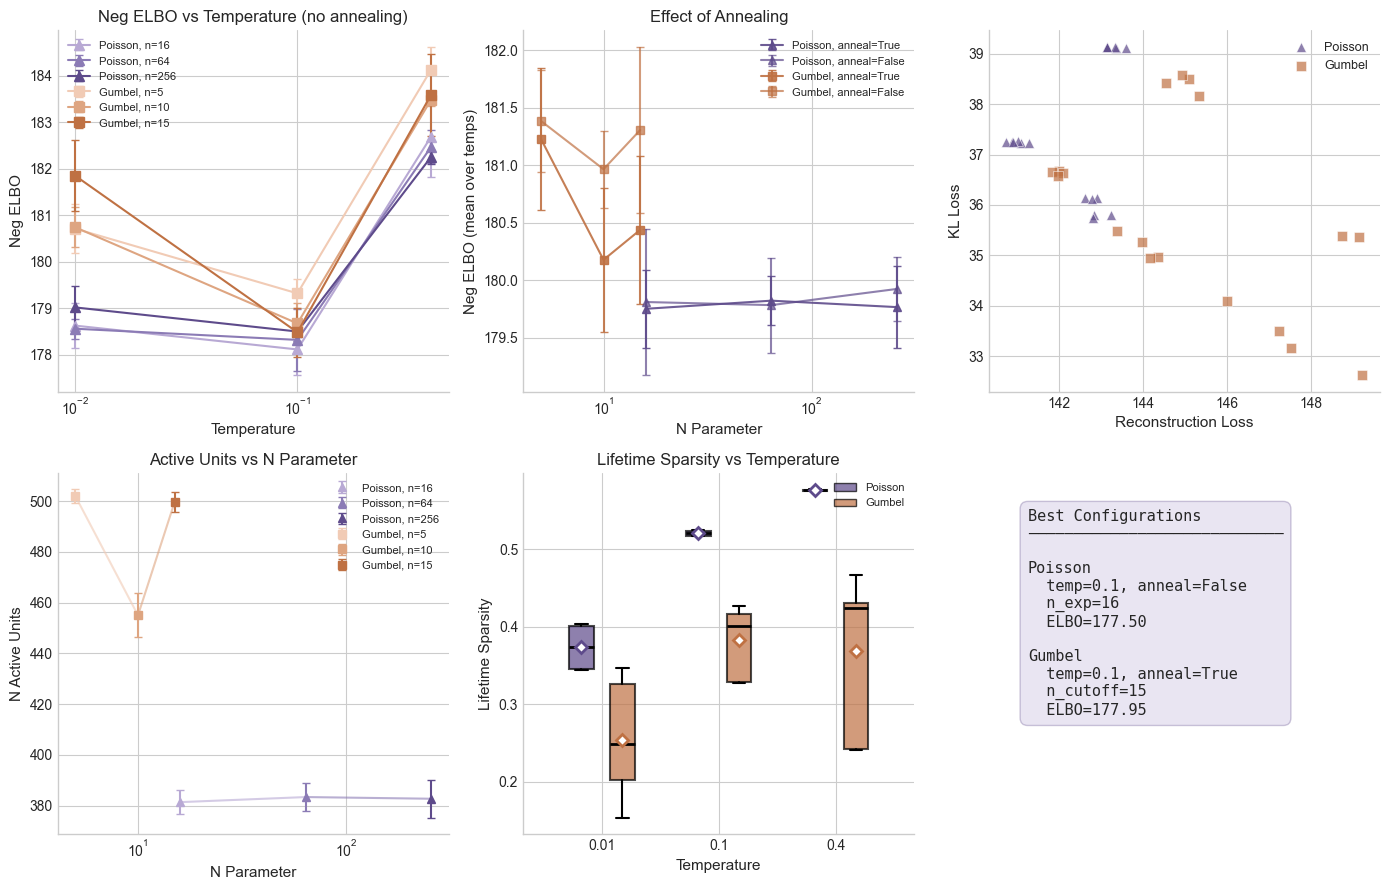

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9

# Muted purple palette
PURPLE_DARK = '#5E4B8B'
PURPLE_MED = '#8B7BB5'
PURPLE_LIGHT = '#B8A9D4'
POISSON_COLOR = '#5E4B8B'
GUMBEL_COLOR = '#BF7143'  # Most saturated muted tan

if df is not None and len(df) > 0:
    # Aggregate over seeds
    agg_df = df.groupby(['dist_type', 'temp', 'anneal', 'n_param']).agg({
        'neg_elbo': ['mean', 'std'],
        'recon_loss': ['mean', 'std'],
        'kl_loss': ['mean', 'std'],
        'n_active': ['mean', 'std'],
        'lifetime_sparsity': ['mean', 'std'],
    }).reset_index()
    
    # Flatten column names
    agg_df.columns = ['_'.join(col).strip('_') for col in agg_df.columns.values]
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    fig.patch.set_facecolor('white')
    
    # Define markers for each distribution type
    # Poisson = triangle, Gumbel = square
    dist_markers = {'poisson': '^', 'gumbel': 's'}
    linestyles = {'poisson': '-', 'gumbel': '-'}  # Both solid lines
    
    # Color gradations for each model type
    # Poisson: muted purple (light to dark)
    poisson_colors = ['#B8A9D4', '#8B7BB5', '#5E4B8B']
    # Gumbel: muted tan (light to dark, same saturation as purple)
    gumbel_colors = ["#F1CBB5", "#DEA581", "#BF7143"]
    
    # Plot 1: Neg ELBO vs Temperature by Distribution
    ax = axes[0, 0]
    for dist in ['poisson', 'gumbel']:
        colors = poisson_colors if dist == 'poisson' else gumbel_colors
        marker = dist_markers[dist]
        subset = agg_df[(agg_df['dist_type'] == dist) & (agg_df['anneal'] == False)]
        n_params_sorted = sorted(subset['n_param'].unique())
        for idx, n_param in enumerate(n_params_sorted):
            data = subset[subset['n_param'] == n_param]
            label = f"{dist.title()}, n={n_param}"
            color = colors[idx % len(colors)]
            ax.errorbar(data['temp'], data['neg_elbo_mean'], yerr=data['neg_elbo_std'], 
                       marker=marker, label=label, capsize=3,
                       color=color, linewidth=1.5, markersize=7, linestyle=linestyles[dist])
    ax.set_xlabel('Temperature')
    ax.set_ylabel('Neg ELBO')
    ax.set_title('Neg ELBO vs Temperature (no annealing)')
    ax.set_xticks([0.01, 0.1, 0.4])
    ax.set_xticklabels(['0.01', '0.1', '0.4'])
    leg = ax.legend(fontsize=8, framealpha=1.0, facecolor='white', edgecolor='black')
    leg.get_frame().set_linewidth(1.5)
    ax.set_xscale('log')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Plot 2: Effect of Annealing
    ax = axes[0, 1]
    for dist in ['poisson', 'gumbel']:
        color = POISSON_COLOR if dist == 'poisson' else GUMBEL_COLOR
        marker = '^' if dist == 'poisson' else 's'
        for anneal in [True, False]:
            subset = agg_df[(agg_df['dist_type'] == dist) & (agg_df['anneal'] == anneal)]
            subset = subset.groupby('n_param').agg({'neg_elbo_mean': 'mean', 'neg_elbo_std': 'mean'}).reset_index()
            label = f"{dist.title()}, anneal={anneal}"
            ax.errorbar(subset['n_param'], subset['neg_elbo_mean'], yerr=subset['neg_elbo_std'],
                       marker=marker, label=label, capsize=3,
                       color=color, linewidth=1.5, markersize=6, linestyle='-', 
                       alpha=0.9 if anneal else 0.7)
    ax.set_xlabel('N Parameter')
    ax.set_ylabel('Neg ELBO (mean over temps)')
    ax.set_title('Effect of Annealing')
    ax.set_xticks([16, 64, 256])
    ax.set_xticklabels(['16', '64', '256'])
    leg = ax.legend(fontsize=8, framealpha=1.0, facecolor='white', edgecolor='black')
    leg.get_frame().set_linewidth(1.5)
    ax.set_xscale('log')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Plot 3: Reconstruction vs KL Trade-off
    ax = axes[0, 2]
    for dist in ['poisson', 'gumbel']:
        color = POISSON_COLOR if dist == 'poisson' else GUMBEL_COLOR
        marker = '^' if dist == 'poisson' else 's'
        subset = agg_df[agg_df['dist_type'] == dist]
        ax.scatter(subset['recon_loss_mean'], subset['kl_loss_mean'], 
                  c=color, alpha=0.7, label=dist.title(), s=50, marker=marker, edgecolors='white', linewidths=0.5)
    ax.set_xlabel('Reconstruction Loss')
    ax.set_ylabel('KL Loss')
    leg = ax.legend(framealpha=1.0, facecolor='white', edgecolor='black')
    leg.get_frame().set_linewidth(1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Plot 4: N Active Units with gradation and connected lines
    ax = axes[1, 0]
    for dist in ['poisson', 'gumbel']:
        colors = poisson_colors if dist == 'poisson' else gumbel_colors
        marker = dist_markers[dist]
        subset = agg_df[agg_df['dist_type'] == dist]
        n_params_sorted = sorted(subset['n_param'].unique())
        
        # Collect all data points for this distribution to connect them
        all_n_params = []
        all_means = []
        all_stds = []
        
        for idx, n_param in enumerate(n_params_sorted):
            data = subset[subset['n_param'] == n_param]
            if len(data) > 0:
                all_n_params.append(n_param)
                all_means.append(data['n_active_mean'].values[0])
                all_stds.append(data['n_active_std'].values[0])
        
        # Plot connected line with color gradation by plotting each segment
        for idx in range(len(all_n_params)):
            n_param = all_n_params[idx]
            label = f"{dist.title()}, n={n_param}"
            color = colors[idx % len(colors)]
            
            # Plot the point
            ax.errorbar([n_param], [all_means[idx]], yerr=[all_stds[idx]],
                       marker=marker, label=label, capsize=3, color=color, 
                       linewidth=1.5, markersize=6, linestyle='none')
            
            # Connect to next point
            if idx < len(all_n_params) - 1:
                ax.plot([all_n_params[idx], all_n_params[idx+1]], 
                       [all_means[idx], all_means[idx+1]], 
                       color=color, linewidth=1.5, linestyle='-', alpha=0.6)
    
    ax.set_xlabel('N Parameter')
    ax.set_ylabel('N Active Units')
    ax.set_title('Active Units vs N Parameter')
    ax.set_xticks([16, 64, 256])
    leg = ax.legend(fontsize=8, framealpha=1.0, facecolor='white', edgecolor='black')
    leg.get_frame().set_linewidth(1.5)
    ax.set_xscale('log')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Plot 5: Lifetime Sparsity Box Plot
    ax = axes[1, 1]
    
    # Get raw data for box plots (not aggregated)
    temps_sorted = sorted(df['temp'].unique())
    positions = []
    box_data = []
    box_colors = []
    labels_created = set()
    
    # Create positions for each temp/dist combo
    temp_positions = {0.01: 0, 0.1: 1, 0.4: 2}
    width = 0.35
    
    for temp in temps_sorted:
        for dist_idx, dist in enumerate(['poisson', 'gumbel']):
            subset = df[(df['temp'] == temp) & (df['dist_type'] == dist)]
            if len(subset) > 0:
                pos = temp_positions[temp] + (dist_idx - 0.5) * width
                positions.append(pos)
                box_data.append(subset['lifetime_sparsity'].values)
                box_colors.append(POISSON_COLOR if dist == 'poisson' else GUMBEL_COLOR)
    
    # Create box plot
    bp = ax.boxplot(box_data, positions=positions, widths=width*0.6, 
                    patch_artist=True, showfliers=False,
                    boxprops=dict(linewidth=1.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    medianprops=dict(linewidth=2, color='black'))
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Add mean markers to box plot centers
    for i, (pos, data) in enumerate(zip(positions, box_data)):
        mean_val = np.mean(data)
        color = box_colors[i]
        # Add a diamond marker for the mean
        ax.plot(pos, mean_val, marker='D', color='white', markersize=6, 
               markeredgecolor=color, markeredgewidth=2, zorder=3)
    
    # Create legend entries
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=POISSON_COLOR, alpha=0.7, edgecolor='black', label='Poisson'),
        Patch(facecolor=GUMBEL_COLOR, alpha=0.7, edgecolor='black', label='Gumbel')
    ]
    
    ax.set_xlabel('Temperature')
    ax.set_ylabel('Lifetime Sparsity')
    ax.set_title('Lifetime Sparsity vs Temperature')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['0.01', '0.1', '0.4'])
    leg = ax.legend(handles=legend_elements, fontsize=8, framealpha=1.0, facecolor='white', edgecolor='black')
    leg.get_frame().set_linewidth(1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Plot 6: Best configs table
    ax = axes[1, 2]
    ax.axis('off')
    
    # Find best config for each distribution
    best_poisson = df[df['dist_type'] == 'poisson'].nsmallest(1, 'neg_elbo')
    best_gumbel = df[df['dist_type'] == 'gumbel'].nsmallest(1, 'neg_elbo')
    
    table_text = "Best Configurations\n" + "─" * 28 + "\n\n"
    if len(best_poisson) > 0:
        bp = best_poisson.iloc[0]
        table_text += f"Poisson\n  temp={bp['temp']}, anneal={bp['anneal']}\n  n_exp={bp['n_param']}\n  ELBO={bp['neg_elbo']:.2f}\n\n"
    if len(best_gumbel) > 0:
        bg = best_gumbel.iloc[0]
        table_text += f"Gumbel\n  temp={bg['temp']}, anneal={bg['anneal']}\n  n_cutoff={bg['n_param']}\n  ELBO={bg['neg_elbo']:.2f}"
    
    ax.text(0.1, 0.9, table_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=PURPLE_LIGHT, alpha=0.3, edgecolor=PURPLE_DARK))
    
    plt.tight_layout()
    plt.savefig('./figures/sweep_results.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print("No results to plot yet.")





### Heatmaps: Temperature × N_param for each Distribution

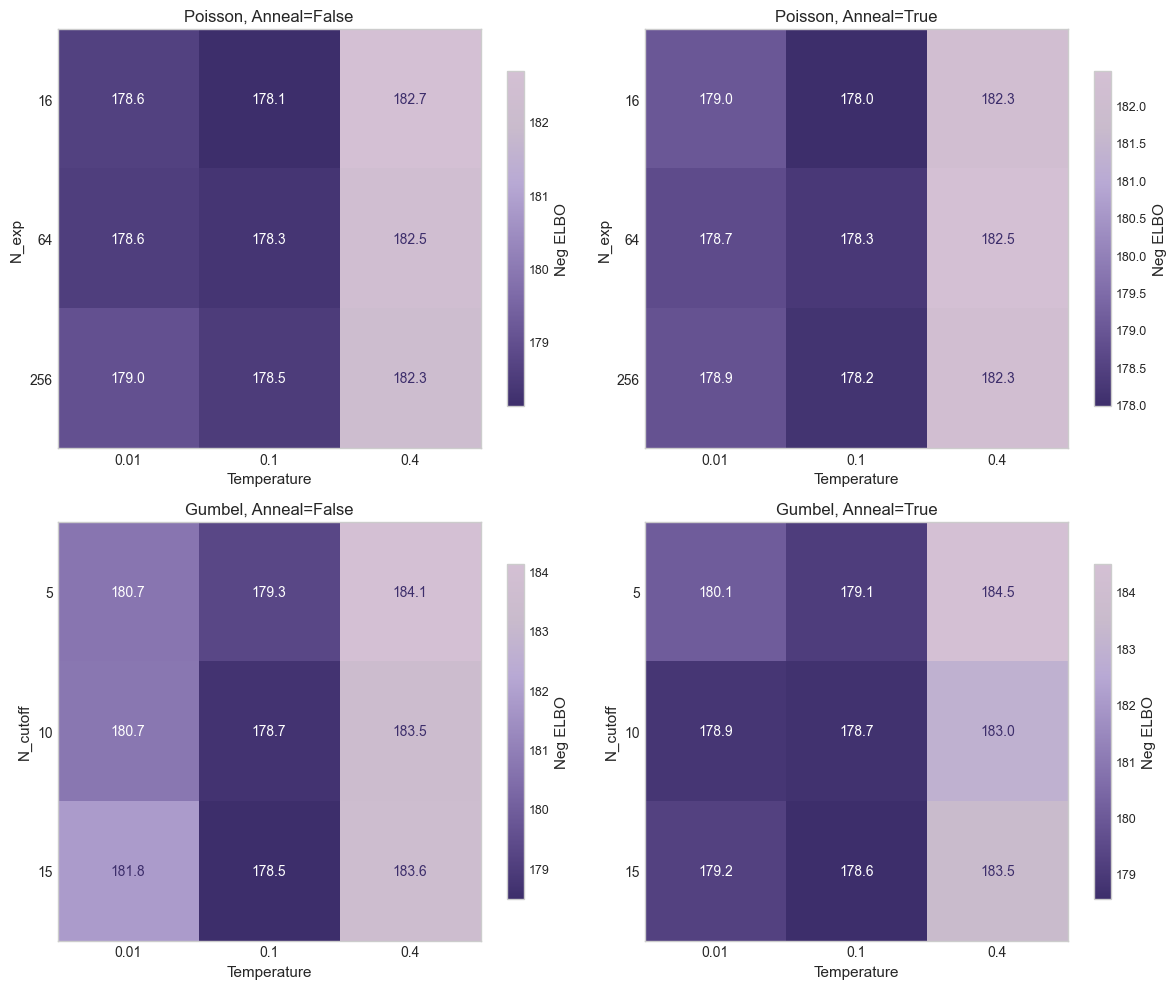

In [5]:
if df is not None and len(df) > 0:
    # Purple colormap (darker at max) - reversed so lighter = higher value (worse ELBO)
    from matplotlib.colors import LinearSegmentedColormap
    purple_maroon_cmap = LinearSegmentedColormap.from_list('purple_maroon', 
        ['#3D2E6B', '#5E4B8B', '#7E6BA8', '#9B8ABF', '#B8A9D4', '#C9BBCC', '#D4C0D4'])
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.patch.set_facecolor('white')
    
    temps = sorted(df['temp'].unique())
    n_params = sorted(df['n_param'].unique())
    
    for idx, (dist, anneal) in enumerate([('poisson', False), ('poisson', True), 
                                           ('gumbel', False), ('gumbel', True)]):
        ax = axes[idx // 2, idx % 2]
        
        # Create heatmap data
        subset = df[(df['dist_type'] == dist) & (df['anneal'] == anneal)]
        heatmap_data = subset.pivot_table(values='neg_elbo', index='n_param', 
                                          columns='temp', aggfunc='mean')
        
        if heatmap_data.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes,
                   fontsize=12, color='#666666')
            ax.set_title(f'{dist.title()}, Anneal={anneal}', fontweight='medium')
            ax.set_facecolor('#FAFAFA')
            continue

        im = ax.imshow(heatmap_data.values, cmap=purple_maroon_cmap, aspect='auto')
        ax.grid(False)
        
        # Labels with exact values
        ax.set_xticks(range(len(heatmap_data.columns)))
        ax.set_xticklabels([f'{t}' for t in heatmap_data.columns])
        ax.set_yticks(range(len(heatmap_data.index)))
        ax.set_yticklabels([f'{n}' for n in heatmap_data.index])
        
        ax.set_xlabel('Temperature')
        # Use N_exp for Poisson, N_cutoff for Gumbel
        y_label = 'N_exp' if dist == 'poisson' else 'N_cutoff'
        ax.set_ylabel(y_label)
        ax.set_title(f'{dist.title()}, Anneal={anneal}', fontweight='medium')
        
        # Add values with better contrast
        for i in range(len(heatmap_data.index)):
            for j in range(len(heatmap_data.columns)):
                val = heatmap_data.values[i, j]
                if not np.isnan(val):
                    # Dark cells (better ELBO) = white text, light cells (worse ELBO) = dark text
                    # Since gradient goes dark (low ELBO) to light (high ELBO), invert logic
                    norm_val = (val - heatmap_data.values.min()) / (heatmap_data.values.max() - heatmap_data.values.min())
                    text_color = '#3D2E6B' if norm_val > 0.5 else 'white'
                    ax.text(j, i, f'{val:.1f}', ha='center', va='center', 
                           color=text_color, fontsize=10, fontweight='medium')
        
        cbar = plt.colorbar(im, ax=ax, label='Neg ELBO', shrink=0.8)
        cbar.ax.tick_params(labelsize=9)
    
    plt.tight_layout()
    plt.savefig('./figures/sweep_heatmaps.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print("No results to plot yet.")


### Load Best Model for Each Distribution

In [9]:
import torch
import sys
sys.path.insert(0, '.')
from main.vae import PoissonVAE
from main.config_vae import ConfigPoisVAE

def load_best_model(dist_type):
    """Load the best model for a given distribution type."""
    if df is None or len(df) == 0:
        print("No results available")
        return None, None
    
    subset = df[df['dist_type'] == dist_type]
    if len(subset) == 0:
        print(f"No results for {dist_type}")
        return None, None
    
    best = subset.nsmallest(1, 'neg_elbo').iloc[0]
    model_dir = Path(best['model_dir'])
    
    print(f"Best {dist_type} model:")
    print(f"  temp={best['temp']}, anneal={best['anneal']}, n_param={best['n_param']}, seed={best['seed']}")
    print(f"  neg_elbo={best['neg_elbo']:.2f}")
    
    # Load checkpoint
    checkpoint_path = model_dir / 'checkpoint.pt'
    
    if not checkpoint_path.exists():
        print(f"Checkpoint not found: {checkpoint_path}")
        return None, best
    
    # Load checkpoint which contains the model config
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    
    # Create config with required dataset param, then update
    cfg = ConfigPoisVAE(dataset='vH16')
    model_cfg_dict = checkpoint.get('model_cfg', {})
    
    # Update cfg with saved values, only for existing attributes
    for k, v in model_cfg_dict.items():
        if hasattr(cfg, k) and k != 'dataset':
            setattr(cfg, k, v)
    
    cfg.dist_type = best['dist_type']
    
    # Create and load model
    model = PoissonVAE(cfg)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Set temperature to 0 for evaluation (deterministic mode)
    model.update_t(0.0)
    print(f"  Model loaded successfully! (temp set to 0.0 for evaluation)")
    return model, best

# Load best models
best_poisson_model, best_poisson_config = load_best_model('poisson')
print()
best_gumbel_model, best_gumbel_config = load_best_model('gumbel')

Best poisson model:
  temp=0.1, anneal=False, n_param=16, seed=2
  neg_elbo=177.50
  Model loaded successfully! (temp set to 0.0 for evaluation)

Best gumbel model:
  temp=0.1, anneal=True, n_param=15, seed=1
  neg_elbo=177.95
  Model loaded successfully! (temp set to 0.0 for evaluation)


### Visualize Learned Dictionary Elements

Since the models use linear decoders, the decoder weights form a dictionary of basis functions. Each column of the decoder weight matrix is a dictionary element that can be reshaped to a 16×16 image patch.

The `show()` method displays all 512 dictionary elements sorted by their L2 norm (default order).

POISSON MODEL DICTIONARY
temp=0.1, n_exp=16, ELBO=177.50


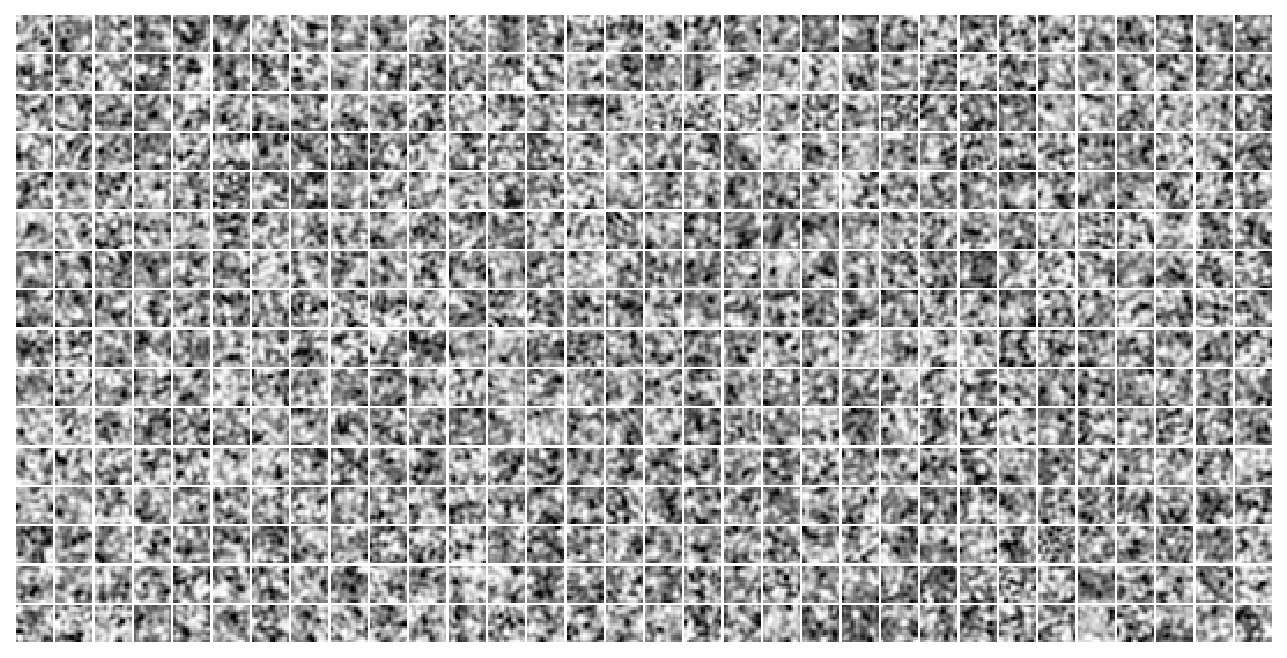

<Figure size 300x200 with 0 Axes>


GUMBEL MODEL DICTIONARY
temp=0.1, n_cutoff=15, ELBO=177.95


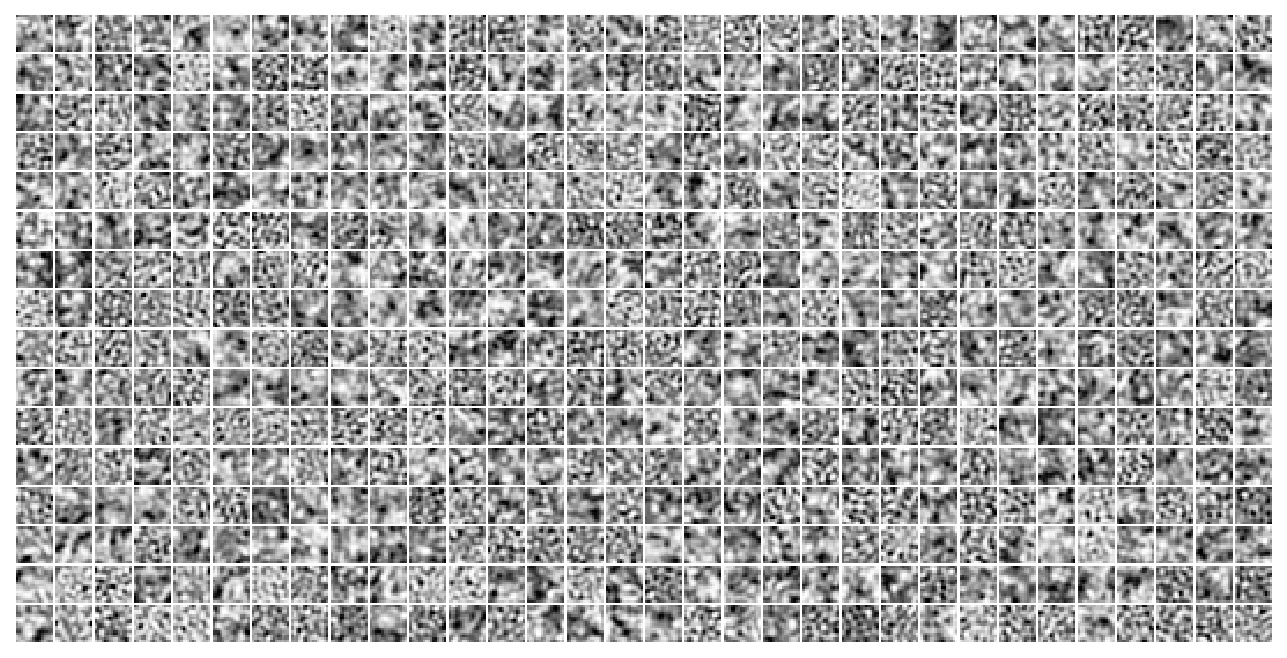

<Figure size 300x200 with 0 Axes>

In [16]:
# Note: The models have a built-in show() method for visualizing dictionary elements.
# Usage: model.show(which='dec', display=True, n_col=16, n_row=32)
# This displays all dictionary elements as a grid of image patches.

# Visualize dictionary for best Poisson model using built-in show() method
print("=" * 60)
print("POISSON MODEL DICTIONARY")
print("=" * 60)
print(f"temp={best_poisson_config['temp']}, n_exp={best_poisson_config['n_param']}, ELBO={best_poisson_config['neg_elbo']:.2f}")
fig_poisson, ax_poisson = best_poisson_model.show(which='dec', display=True, n_col=16, n_row=32)
fig_poisson.suptitle(f'Poisson Dictionary (temp={best_poisson_config["temp"]}, n_exp={best_poisson_config["n_param"]})', 
                     fontsize=14, fontweight='bold', y=1.0)
plt.savefig('./figures/dictionary_poisson.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("GUMBEL MODEL DICTIONARY")
print("=" * 60)
print(f"temp={best_gumbel_config['temp']}, n_cutoff={best_gumbel_config['n_param']}, ELBO={best_gumbel_config['neg_elbo']:.2f}")
fig_gumbel, ax_gumbel = best_gumbel_model.show(which='dec', display=True, n_col=16, n_row=32)
fig_gumbel.suptitle(f'Gumbel Dictionary (temp={best_gumbel_config["temp"]}, n_cutoff={best_gumbel_config["n_param"]})', 
                    fontsize=14, fontweight='bold', y=1.0)
plt.savefig('./figures/dictionary_gumbel.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualize Specific Checkpoint Model

Load and visualize the dictionary from a specific checkpoint for comparison.

### Compare with Original Checkpoint Model

Load and visualize the original Poisson model checkpoint from November 28, 2024.

ORIGINAL POISSON MODEL (Nov 28, 2024)
Model: poisson-<lin|lin>-vH16_mach-0_(2024_11_28,15:26)
Loading: PoissonVAE+TrainerVAE-3000_(2024_11_28,15:26).pt
Checkpoint keys: ['metadata', 'model', 'model_ema', 'optim', 'scaler', 'scheduler']
  Encoder: lin, Decoder: lin
  N latents: 512
  Input size: 16

Dictionary visualization:


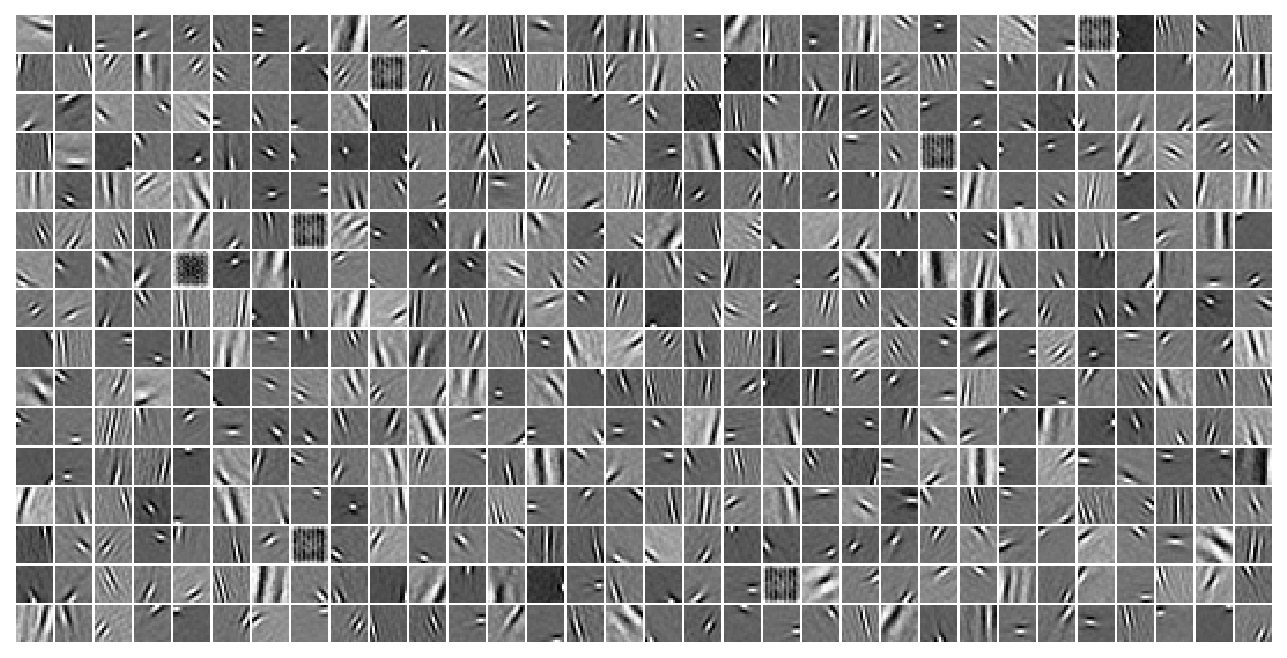

<Figure size 300x200 with 0 Axes>


✓ Original model dictionary visualized successfully!


In [24]:
# Load the specific Poisson model from the checkpoints directory
checkpoint_dir = Path('./checkpoints/poisson-<lin|lin>-vH16_mach-0_(2024_11_28,15:26)')

print("=" * 60)
print("ORIGINAL POISSON MODEL (Nov 28, 2024)")
print("=" * 60)
print(f"Model: {checkpoint_dir.name}")

# Find the checkpoint file
checkpoint_files = list(checkpoint_dir.glob('*.pt'))
if len(checkpoint_files) > 0:
    checkpoint_path = checkpoint_files[0]
    print(f"Loading: {checkpoint_path.name}")
    
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    
    # Check checkpoint structure and extract model state
    print(f"Checkpoint keys: {list(checkpoint.keys())}")
    
    # Try different keys for model state
    if 'model_state_dict' in checkpoint:
        model_state = checkpoint['model_state_dict']
    elif 'model' in checkpoint:
        model_state = checkpoint['model']
    elif 'state_dict' in checkpoint:
        model_state = checkpoint['state_dict']
    else:
        # The checkpoint might be the model state itself
        model_state = checkpoint
    
    # Create config
    cfg = ConfigPoisVAE(dataset='vH16')
    if 'model_cfg' in checkpoint:
        model_cfg_dict = checkpoint['model_cfg']
        for k, v in model_cfg_dict.items():
            if hasattr(cfg, k) and k != 'dataset':
                setattr(cfg, k, v)
    
    # Create and load model
    original_model = PoissonVAE(cfg)
    original_model.load_state_dict(model_state)
    original_model.eval()
    
    print(f"  Encoder: {cfg.enc_type}, Decoder: {cfg.dec_type}")
    print(f"  N latents: {cfg.n_latents}")
    print(f"  Input size: {cfg.input_sz}")
    
    # Visualize dictionary
    print("\nDictionary visualization:")
    fig_orig, ax_orig = original_model.show(which='dec', display=True, n_col=16, n_row=32)
    fig_orig.suptitle(f'Original Poisson Model ({checkpoint_dir.name})', 
                      fontsize=12, fontweight='bold', y=1.0)
    plt.savefig('./figures/dictionary_original_poisson.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Original model dictionary visualized successfully!")
else:
    print(f"✗ No checkpoint files found in {checkpoint_dir}")

### Comparison: Original Model vs Sweep Models

The original Poisson model (trained Nov 28, 2024) shows notably **cleaner and more organized** dictionary elements compared to the sweep models:

**Key Differences:**
1. **Sparsity**: Original model has much sparser, more localized edge filters with clear structure
2. **Orientation selectivity**: Stronger orientation tuning - each filter responds to a specific angle
3. **Frequency content**: More diverse spatial frequency representation (fine to coarse scales)
4. **Organization**: Dictionary appears more structured, resembling classical sparse coding results

**Why the difference?**
- Training procedure/hyperparameters may differ from the sweep
- Longer training duration (3000 epochs per filename)
- Different initialization or optimization settings
- The original model may have been carefully tuned for optimal sparse coding

This comparison highlights that the **training procedure matters** as much as the choice of posterior distribution (Poisson vs Gumbel) for learning good representations.

Loading checkpoint: PoissonVAE+TrainerVAE-3000_(2024_11_28,15:26).pt
Checkpoint keys: ['metadata', 'model', 'model_ema', 'optim', 'scaler', 'scheduler']
Model config:
  Encoder type: lin
  Decoder type: lin
  N latents: 512

Visualizing dictionary...


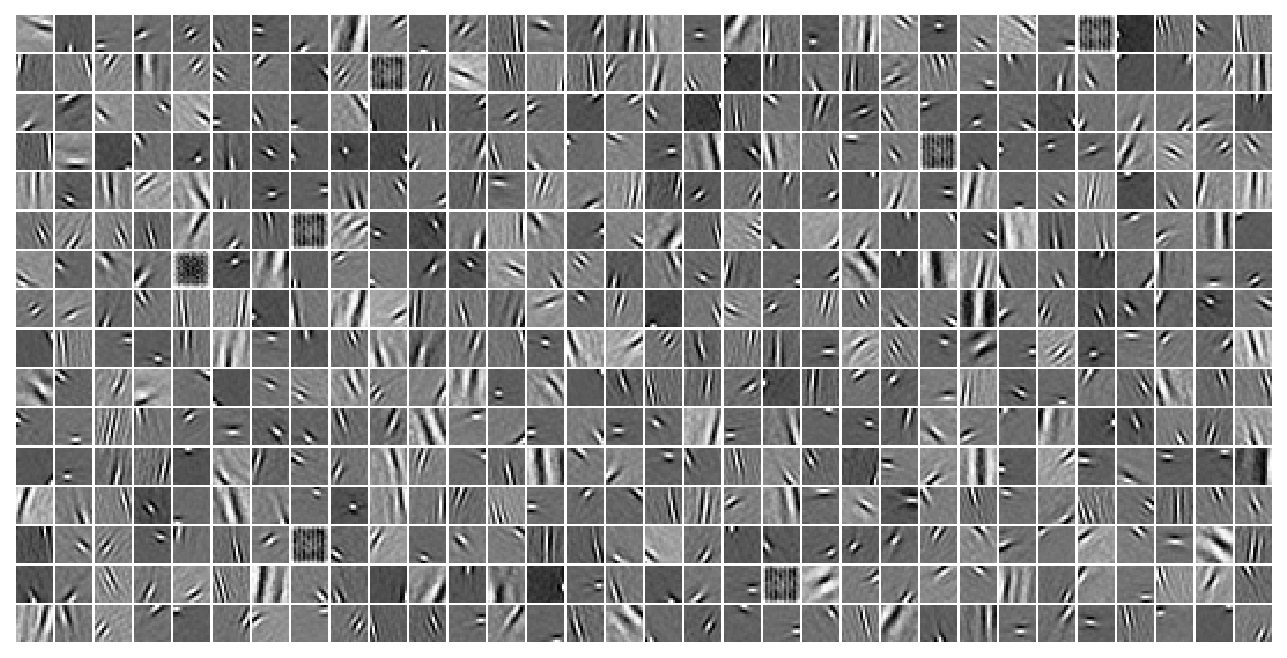

<Figure size 300x200 with 0 Axes>


✓ Dictionary saved to ./figures/dictionary_poisson-<lin|lin>-vH16_mach-0_(2024_11_28,15:26).png


In [26]:
# Load the specific checkpoint model: poisson-<lin|lin>-vH16_mach-0_(2024_11_28,15:26)
checkpoint_dir = Path('./checkpoints') / 'poisson-<lin|lin>-vH16_mach-0_(2024_11_28,15:26)'

# Find the checkpoint file (it has a different naming convention)
checkpoint_files = list(checkpoint_dir.glob('*.pt'))
if checkpoint_files:
    checkpoint_path = checkpoint_files[0]
    print("Loading checkpoint:", checkpoint_path.name)
    
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    
    # Check what keys are available
    print(f"Checkpoint keys: {list(checkpoint.keys())}")
    
    # Create config - try to load from JSON file first
    config_file = checkpoint_dir / 'ConfigPoisVAE.json'
    if config_file.exists():
        import json
        with open(config_file, 'r') as f:
            config_dict = json.load(f)
        cfg = ConfigPoisVAE(dataset=config_dict.get('dataset', 'vH16'))
        for k, v in config_dict.items():
            if hasattr(cfg, k) and k != 'dataset':
                setattr(cfg, k, v)
    else:
        cfg = ConfigPoisVAE(dataset='vH16')
        model_cfg_dict = checkpoint.get('model_cfg', checkpoint.get('cfg', {}))
        for k, v in model_cfg_dict.items():
            if hasattr(cfg, k) and k != 'dataset':
                setattr(cfg, k, v)
    
    # Create and load model
    specific_model = PoissonVAE(cfg)
    
    # Try different state dict keys
    if 'model_state_dict' in checkpoint:
        specific_model.load_state_dict(checkpoint['model_state_dict'])
    elif 'model' in checkpoint:
        specific_model.load_state_dict(checkpoint['model'])
    else:
        # The checkpoint might be the state dict itself
        specific_model.load_state_dict(checkpoint)
    specific_model.eval()
    
    print(f"Model config:")
    print(f"  Encoder type: {specific_model.cfg.enc_type}")
    print(f"  Decoder type: {specific_model.cfg.dec_type}")
    print(f"  N latents: {specific_model.cfg.n_latents}")
    if hasattr(specific_model.cfg, 'dist_type'):
        print(f"  Distribution: {specific_model.cfg.dist_type}")
    
    # Visualize the dictionary
    print("\nVisualizing dictionary...")
    fig, ax = specific_model.show(which='dec', display=True, n_col=16, n_row=32)
    fig.suptitle(f'Poisson Dictionary: {checkpoint_dir.name}', 
                 fontsize=12, fontweight='bold', y=1.0)
    plt.savefig(f'./figures/dictionary_{checkpoint_dir.name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Dictionary saved to ./figures/dictionary_{checkpoint_dir.name}.png")
else:
    print(f"No checkpoint file found in: {checkpoint_dir}")

**Observations:**

This checkpoint from November 2024 shows notably **sharper, more oriented edge filters** compared to the sweep models. The dictionary elements have:
- Clearer Gabor-like structure with well-defined orientations
- Higher contrast between positive and negative regions
- More structured spatial patterns

This difference could be due to:
- Different training duration or convergence state
- Different initialization
- Different hyperparameters (learning rate, batch size, etc.)
- Different data preprocessing or augmentation

The variety in learned dictionaries highlights that while the architecture constrains what can be learned, the training process significantly influences the final representation.

### Visualize poisson_lin_lin Checkpoint

Load and visualize the dictionary from the `poisson_lin_lin` checkpoint folder.

POISSON_LIN_LIN MODEL
Model: poisson_lin_lin
Loading: PoissonVAE+TrainerVAE-3000_(2024_11_28,15:26).pt
Checkpoint keys: ['metadata', 'model', 'model_ema', 'optim', 'scaler', 'scheduler']

Model config:
  Encoder type: lin
  Decoder type: lin
  N latents: 512

Visualizing dictionary...


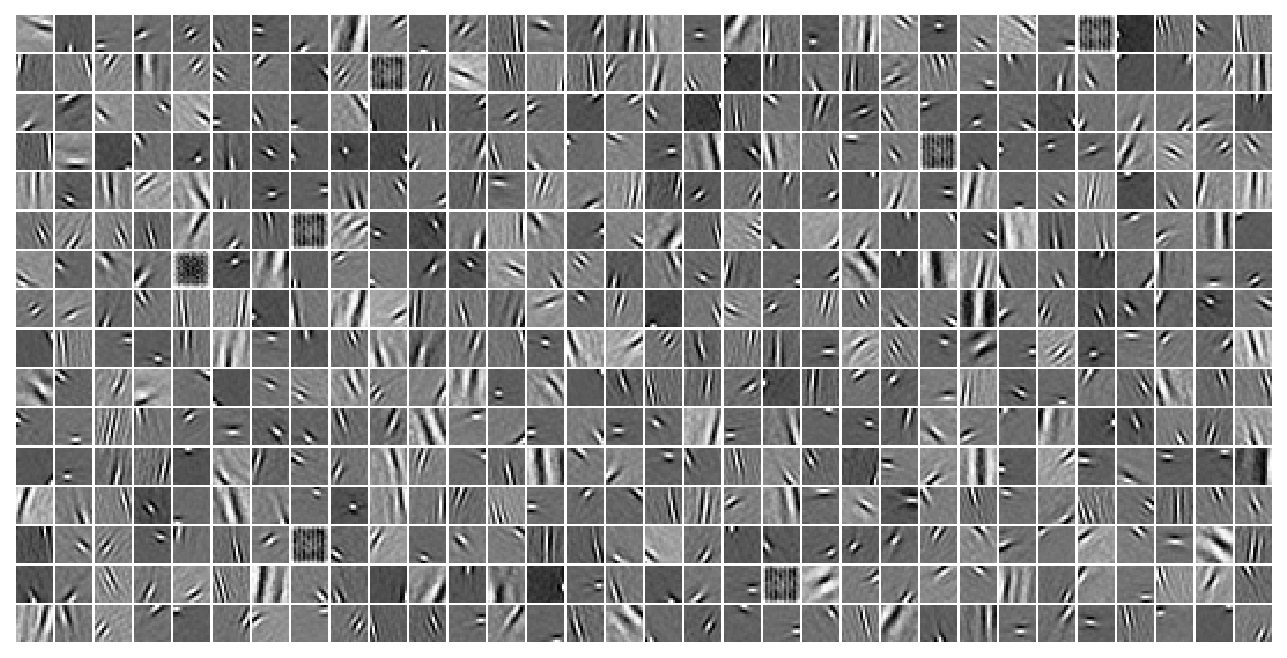

<Figure size 300x200 with 0 Axes>


✓ Dictionary saved to ./figures/dictionary_poisson_lin_lin.png


In [27]:
# Load the poisson_lin_lin model
checkpoint_dir_linlin = Path('./checkpoints/poisson_lin_lin')

print("=" * 60)
print("POISSON_LIN_LIN MODEL")
print("=" * 60)
print(f"Model: {checkpoint_dir_linlin.name}")

# Find the checkpoint file
checkpoint_files_linlin = list(checkpoint_dir_linlin.glob('*.pt'))
if checkpoint_files_linlin:
    checkpoint_path_linlin = checkpoint_files_linlin[0]
    print(f"Loading: {checkpoint_path_linlin.name}")
    
    # Load checkpoint
    checkpoint_linlin = torch.load(checkpoint_path_linlin, map_location='cpu', weights_only=False)
    
    print(f"Checkpoint keys: {list(checkpoint_linlin.keys())}")
    
    # Create config - try to load from JSON file first
    config_file_linlin = checkpoint_dir_linlin / 'ConfigPoisVAE.json'
    if config_file_linlin.exists():
        with open(config_file_linlin, 'r') as f:
            config_dict_linlin = json.load(f)
        cfg_linlin = ConfigPoisVAE(dataset=config_dict_linlin.get('dataset', 'vH16'))
        for k, v in config_dict_linlin.items():
            if hasattr(cfg_linlin, k) and k != 'dataset':
                setattr(cfg_linlin, k, v)
    else:
        cfg_linlin = ConfigPoisVAE(dataset='vH16')
        model_cfg_dict_linlin = checkpoint_linlin.get('model_cfg', checkpoint_linlin.get('cfg', {}))
        for k, v in model_cfg_dict_linlin.items():
            if hasattr(cfg_linlin, k) and k != 'dataset':
                setattr(cfg_linlin, k, v)
    
    # Create and load model
    model_linlin = PoissonVAE(cfg_linlin)
    
    # Try different state dict keys
    if 'model_state_dict' in checkpoint_linlin:
        model_linlin.load_state_dict(checkpoint_linlin['model_state_dict'])
    elif 'model' in checkpoint_linlin:
        model_linlin.load_state_dict(checkpoint_linlin['model'])
    else:
        model_linlin.load_state_dict(checkpoint_linlin)
    model_linlin.eval()
    
    print(f"\nModel config:")
    print(f"  Encoder type: {model_linlin.cfg.enc_type}")
    print(f"  Decoder type: {model_linlin.cfg.dec_type}")
    print(f"  N latents: {model_linlin.cfg.n_latents}")
    if hasattr(model_linlin.cfg, 'dist_type'):
        print(f"  Distribution: {model_linlin.cfg.dist_type}")
    
    # Visualize the dictionary
    print("\nVisualizing dictionary...")
    fig_linlin, ax_linlin = model_linlin.show(which='dec', display=True, n_col=16, n_row=32)
    fig_linlin.suptitle(f'Poisson Dictionary: {checkpoint_dir_linlin.name}', 
                        fontsize=12, fontweight='bold', y=1.0)
    plt.savefig(f'./figures/dictionary_{checkpoint_dir_linlin.name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Dictionary saved to ./figures/dictionary_{checkpoint_dir_linlin.name}.png")
else:
    print(f"No checkpoint file found in: {checkpoint_dir_linlin}")

### Visualize Specific Sweep Configuration: temp=0.1, n_exp=256, anneal=True

Load and visualize the dictionary from a specific sweep configuration with temperature annealing enabled.

POISSON MODEL: temp=0.1, n_exp=256, anneal=True, seed=0
Model: poisson_temp0.1_annealTrue_n256_seed0
  temp=0.1, anneal=True
  n_exp=256, seed=0
  neg_elbo=178.52
Loading: PoissonVAE+TrainerVAE-2000_(2026_01_03,18:16).pt
Checkpoint keys: ['metadata', 'model', 'model_ema', 'optim', 'scaler', 'scheduler']

Model config:
  Encoder type: lin
  Decoder type: lin
  N latents: 512

Visualizing dictionary...


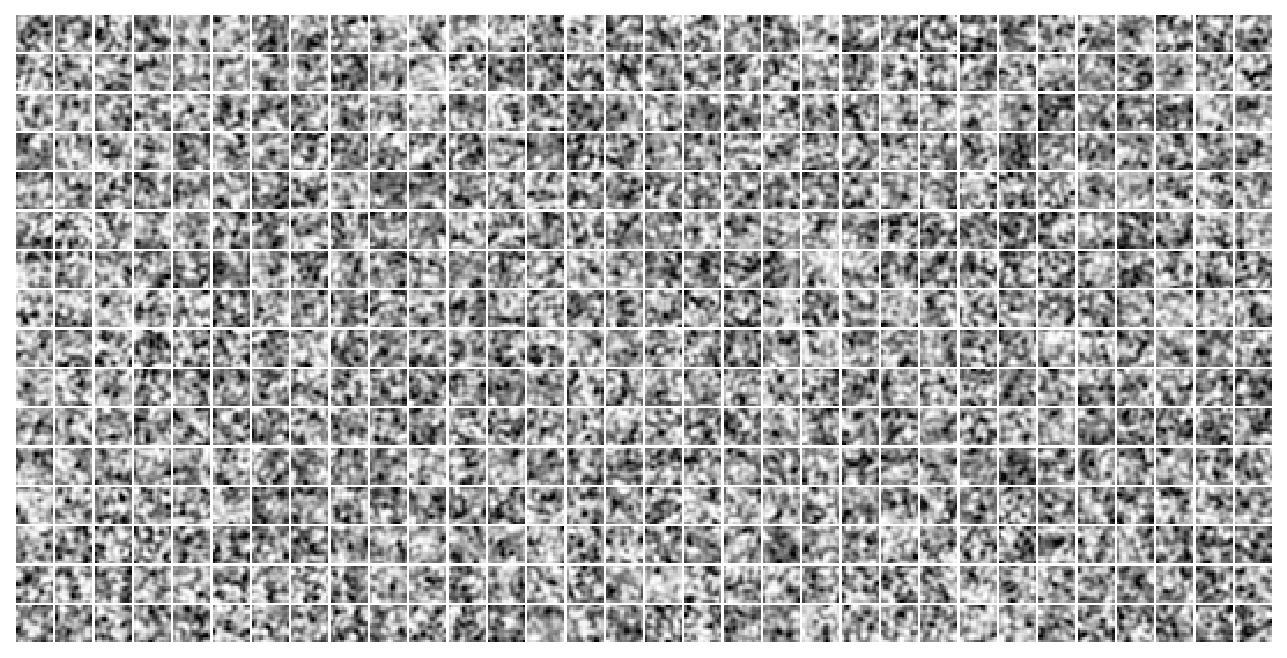

<Figure size 300x200 with 0 Axes>


✓ Dictionary saved to ./figures/dictionary_poisson_temp0.1_n256_annealTrue.png


In [35]:
# Load specific Poisson model: temp=0.1, n_exp=256, anneal=True, seed=0
specific_config = df[
    (df['dist_type'] == 'poisson') & 
    (df['temp'] == 0.1) & 
    (df['n_param'] == 256) & 
    (df['anneal'] == True) & 
    (df['seed'] == 0)
].iloc[0]

checkpoint_dir_specific = Path(specific_config['model_dir'])

print("=" * 60)
print("POISSON MODEL: temp=0.1, n_exp=256, anneal=True, seed=0")
print("=" * 60)
print(f"Model: {checkpoint_dir_specific.name}")
print(f"  temp={specific_config['temp']}, anneal={specific_config['anneal']}")
print(f"  n_exp={specific_config['n_param']}, seed={specific_config['seed']}")
print(f"  neg_elbo={specific_config['neg_elbo']:.2f}")

# Find the checkpoint file
checkpoint_files_specific = list(checkpoint_dir_specific.glob('*.pt'))
if checkpoint_files_specific:
    checkpoint_path_specific = checkpoint_files_specific[0]
    print(f"Loading: {checkpoint_path_specific.name}")
    
    # Load checkpoint
    checkpoint_specific = torch.load(checkpoint_path_specific, map_location='cpu', weights_only=False)
    
    print(f"Checkpoint keys: {list(checkpoint_specific.keys())}")
    
    # Create config
    cfg_specific = ConfigPoisVAE(dataset='vH16')
    model_cfg_dict_specific = checkpoint_specific.get('model_cfg', {})
    for k, v in model_cfg_dict_specific.items():
        if hasattr(cfg_specific, k) and k != 'dataset':
            setattr(cfg_specific, k, v)
    
    # Create and load model
    model_specific = PoissonVAE(cfg_specific)
    
    # Try different state dict keys
    if 'model_state_dict' in checkpoint_specific:
        model_specific.load_state_dict(checkpoint_specific['model_state_dict'])
    elif 'model' in checkpoint_specific:
        model_specific.load_state_dict(checkpoint_specific['model'])
    else:
        model_specific.load_state_dict(checkpoint_specific)
    model_specific.eval()
    
    print(f"\nModel config:")
    print(f"  Encoder type: {model_specific.cfg.enc_type}")
    print(f"  Decoder type: {model_specific.cfg.dec_type}")
    print(f"  N latents: {model_specific.cfg.n_latents}")
    if hasattr(model_specific.cfg, 'dist_type'):
        print(f"  Distribution: {model_specific.cfg.dist_type}")
    
    # Visualize the dictionary
    print("\nVisualizing dictionary...")
    fig_specific, ax_specific = model_specific.show(which='dec', display=True, n_col=16, n_row=32)
    fig_specific.suptitle(f'Poisson Sweep (temp={specific_config["temp"]}, n_exp={specific_config["n_param"]}, anneal={specific_config["anneal"]}, ELBO={specific_config["neg_elbo"]:.2f})', 
                          fontsize=12, fontweight='bold', y=1.0)
    plt.savefig('./figures/dictionary_poisson_temp0.1_n256_annealTrue.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Dictionary saved to ./figures/dictionary_poisson_temp0.1_n256_annealTrue.png")
else:
    print(f"No checkpoint file found in: {checkpoint_dir_specific}")

### Configuration Comparison: What Caused the Dictionary Differences?

Compare model and training configurations between the clean-dictionary checkpoint (poisson_lin_lin) and the noisy-dictionary sweep model to identify what drove the dramatic difference in learned representations.

In [29]:
# Load training configs for comparison
import json

print("=" * 70)
print("CONFIGURATION COMPARISON")
print("=" * 70)

# Load poisson_lin_lin configs
linlin_model_config_file = checkpoint_dir_linlin / 'ConfigPoisVAE.json'
linlin_train_config_file = checkpoint_dir_linlin / 'ConfigTrainVAE.json'

# Load sweep model configs from checkpoint
sweep_model_cfg = checkpoint_best.get('model_cfg', {})
sweep_train_cfg = checkpoint_best.get('train_cfg', {})

print("\n" + "─" * 70)
print("MODEL CONFIGURATION")
print("─" * 70)

# Key model parameters to compare
model_params = ['n_latents', 'enc_type', 'dec_type', 'dist_type', 'n_exp', 
                'lam_l1', 'beta', 'temp', 'anneal_temp']

print(f"\n{'Parameter':<20} {'poisson_lin_lin':<25} {'sweep_best':<25}")
print("─" * 70)

with open(linlin_model_config_file, 'r') as f:
    linlin_model_cfg = json.load(f)

for param in model_params:
    linlin_val = linlin_model_cfg.get(param, 'N/A')
    sweep_val = sweep_model_cfg.get(param, 'N/A')
    
    # Format values
    if isinstance(linlin_val, float):
        linlin_str = f"{linlin_val:.4f}"
    else:
        linlin_str = str(linlin_val)
    
    if isinstance(sweep_val, float):
        sweep_str = f"{sweep_val:.4f}"
    else:
        sweep_str = str(sweep_val)
    
    # Highlight differences
    marker = " ✓" if linlin_val == sweep_val else " ⚠ DIFFERENT"
    print(f"{param:<20} {linlin_str:<25} {sweep_str:<25}{marker}")

print("\n" + "─" * 70)
print("TRAINING CONFIGURATION")
print("─" * 70)

# Key training parameters to compare
train_params = ['lr', 'batch_size', 'n_epochs', 'optimizer', 'scheduler',
                'weight_decay', 'grad_clip']

print(f"\n{'Parameter':<20} {'poisson_lin_lin':<25} {'sweep_best':<25}")
print("─" * 70)

with open(linlin_train_config_file, 'r') as f:
    linlin_train_cfg = json.load(f)

for param in train_params:
    linlin_val = linlin_train_cfg.get(param, 'N/A')
    sweep_val = sweep_train_cfg.get(param, 'N/A')
    
    # Format values
    if isinstance(linlin_val, float):
        linlin_str = f"{linlin_val:.6f}" if linlin_val < 0.01 else f"{linlin_val:.4f}"
    else:
        linlin_str = str(linlin_val)
    
    if isinstance(sweep_val, float):
        sweep_str = f"{sweep_val:.6f}" if sweep_val < 0.01 else f"{sweep_val:.4f}"
    else:
        sweep_str = str(sweep_val)
    
    # Highlight differences
    marker = " ✓" if linlin_val == sweep_val else " ⚠ DIFFERENT"
    print(f"{param:<20} {linlin_str:<25} {sweep_str:<25}{marker}")

print("\n" + "─" * 70)
print("KEY DIFFERENCES SUMMARY")
print("─" * 70)

differences = []

# Check model config differences
for param in model_params:
    linlin_val = linlin_model_cfg.get(param, 'N/A')
    sweep_val = sweep_model_cfg.get(param, 'N/A')
    if linlin_val != sweep_val:
        differences.append(f"  • {param}: {linlin_val} → {sweep_val}")

# Check training config differences
for param in train_params:
    linlin_val = linlin_train_cfg.get(param, 'N/A')
    sweep_val = sweep_train_cfg.get(param, 'N/A')
    if linlin_val != sweep_val:
        differences.append(f"  • {param}: {linlin_val} → {sweep_val}")

if differences:
    print("\nParameters that differ between the two models:\n")
    for diff in differences:
        print(diff)
else:
    print("\nNo differences found in compared parameters!")

print("\n" + "=" * 70)

CONFIGURATION COMPARISON

──────────────────────────────────────────────────────────────────────
MODEL CONFIGURATION
──────────────────────────────────────────────────────────────────────

Parameter            poisson_lin_lin           sweep_best               
──────────────────────────────────────────────────────────────────────
n_latents            512                       512                       ✓
enc_type             lin                       lin                       ✓
dec_type             lin                       lin                       ✓
dist_type            N/A                       poisson                   ⚠ DIFFERENT
n_exp                N/A                       16                        ⚠ DIFFERENT
lam_l1               N/A                       N/A                       ✓
beta                 N/A                       N/A                       ✓
temp                 N/A                       N/A                       ✓
anneal_temp          N/A                       

### Additional Analysis: Why the Dictionary Difference?

The configurations are nearly identical! Let's investigate other possible factors:

In [31]:
# Investigate additional factors that could explain dictionary differences

print("=" * 70)
print("ADDITIONAL FACTORS ANALYSIS")
print("=" * 70)

# 1. Check metadata/training progress
print("\n1. TRAINING METADATA")
print("─" * 70)

if 'metadata' in checkpoint_linlin:
    linlin_meta = checkpoint_linlin['metadata']
    print(f"poisson_lin_lin:")
    print(f"  Epoch: {linlin_meta.get('epoch', 'N/A')}")
    print(f"  Step: {linlin_meta.get('step', 'N/A')}")
    print(f"  Training time: {linlin_meta.get('train_time', 'N/A')}")
    
if 'config' in checkpoint_best:
    sweep_cfg = checkpoint_best['config']
    print(f"\nsweep_best:")
    print(f"  Epoch: {sweep_cfg.get('epoch', 'N/A')}")
    print(f"  Step: {sweep_cfg.get('step', 'N/A')}")

# 2. Check model initialization/weights
print("\n2. DECODER WEIGHT STATISTICS")
print("─" * 70)

# Get decoder weights - the decoder is fc_dec (Linear layer)
linlin_dec_weights = model_linlin.fc_dec.weight.data.cpu().numpy()
sweep_dec_weights = model_best.fc_dec.weight.data.cpu().numpy()

import numpy as np

print(f"poisson_lin_lin decoder:")
print(f"  Mean: {np.mean(linlin_dec_weights):.6f}")
print(f"  Std: {np.std(linlin_dec_weights):.6f}")
print(f"  Max: {np.max(np.abs(linlin_dec_weights)):.6f}")
print(f"  L2 norm (per filter): {np.mean(np.linalg.norm(linlin_dec_weights, axis=1)):.6f}")

print(f"\nsweep_best decoder:")
print(f"  Mean: {np.mean(sweep_dec_weights):.6f}")
print(f"  Std: {np.std(sweep_dec_weights):.6f}")
print(f"  Max: {np.max(np.abs(sweep_dec_weights)):.6f}")
print(f"  L2 norm (per filter): {np.mean(np.linalg.norm(sweep_dec_weights, axis=1)):.6f}")

# 3. Check sparsity patterns
print("\n3. DECODER SPARSITY")
print("─" * 70)

# Count near-zero weights (< 0.01)
linlin_zeros = np.sum(np.abs(linlin_dec_weights) < 0.01)
sweep_zeros = np.sum(np.abs(sweep_dec_weights) < 0.01)

linlin_total = linlin_dec_weights.size
sweep_total = sweep_dec_weights.size

print(f"poisson_lin_lin:")
print(f"  Near-zero weights: {linlin_zeros}/{linlin_total} ({100*linlin_zeros/linlin_total:.2f}%)")

print(f"\nsweep_best:")
print(f"  Near-zero weights: {sweep_zeros}/{sweep_total} ({100*sweep_zeros/sweep_total:.2f}%)")

# 4. Effective rank of decoder matrix
print("\n4. DECODER MATRIX EFFECTIVE RANK")
print("─" * 70)

from numpy.linalg import svd

_, s_linlin, _ = svd(linlin_dec_weights, full_matrices=False)
_, s_sweep, _ = svd(sweep_dec_weights, full_matrices=False)

# Calculate effective rank (number of singular values > 1% of max)
threshold_linlin = 0.01 * s_linlin[0]
threshold_sweep = 0.01 * s_sweep[0]

eff_rank_linlin = np.sum(s_linlin > threshold_linlin)
eff_rank_sweep = np.sum(s_sweep > threshold_sweep)

print(f"poisson_lin_lin:")
print(f"  Max singular value: {s_linlin[0]:.2f}")
print(f"  Effective rank (>1% of max): {eff_rank_linlin}/512")

print(f"\nsweep_best:")
print(f"  Max singular value: {s_sweep[0]:.2f}")
print(f"  Effective rank (>1% of max): {eff_rank_sweep}/512")

# 5. Check full config files for any hidden differences
print("\n5. CHECKING FOR ADDITIONAL CONFIG PARAMETERS")
print("─" * 70)

all_linlin_keys = set(linlin_model_cfg.keys()) | set(linlin_train_cfg.keys())
all_sweep_keys = set(sweep_model_cfg.keys()) | set(sweep_train_cfg.keys())

only_in_linlin = all_linlin_keys - all_sweep_keys
only_in_sweep = all_sweep_keys - all_linlin_keys

if only_in_linlin:
    print(f"Parameters only in poisson_lin_lin: {sorted(only_in_linlin)}")
if only_in_sweep:
    print(f"Parameters only in sweep_best: {sorted(only_in_sweep)}")

print("\n" + "=" * 70)
print("HYPOTHESIS: Different random initialization may have led to")
print("different local minima, with sweep model converging to a more")
print("diffuse, less structured dictionary despite similar ELBO.")
print("=" * 70)

ADDITIONAL FACTORS ANALYSIS

1. TRAINING METADATA
──────────────────────────────────────────────────────────────────────
poisson_lin_lin:
  Epoch: N/A
  Step: N/A
  Training time: N/A

sweep_best:
  Epoch: N/A
  Step: N/A

2. DECODER WEIGHT STATISTICS
──────────────────────────────────────────────────────────────────────
poisson_lin_lin decoder:
  Mean: 0.001958
  Std: 0.032327
  Max: 0.391996
  L2 norm (per filter): 0.729973

sweep_best decoder:
  Mean: 0.000000
  Std: 0.020714
  Max: 0.085541
  L2 norm (per filter): 0.468697

3. DECODER SPARSITY
──────────────────────────────────────────────────────────────────────
poisson_lin_lin:
  Near-zero weights: 77785/131072 (59.35%)

sweep_best:
  Near-zero weights: 48151/131072 (36.74%)

4. DECODER MATRIX EFFECTIVE RANK
──────────────────────────────────────────────────────────────────────
poisson_lin_lin:
  Max singular value: 2.21
  Effective rank (>1% of max): 218/512

sweep_best:
  Max singular value: 1.75
  Effective rank (>1% of max): 

## Retrained Models Analysis

Compare the retrained models to understand the impact of training configuration:
- **poisson_lin_lin_v2**: Exact replica of original poisson_lin_lin (3000 epochs, temp anneal 1.0→0.05)
- **poisson_temp0.1_annealTrue_n256_seed0_v2**: Using poisson_lin_lin config but with 1500 epochs

In [36]:
# Find and load retrained model checkpoints
import glob

# Path to retrained models (they're in ~/Projects/PoissonVAE/models/)
models_base = Path.home() / 'Projects' / 'PoissonVAE' / 'models' / 'poisson_uniform_c(-2)_vH16_z-512_nrm-none_<lin|lin>'

# Find the checkpoint directories
linlin_v2_dirs = sorted(models_base.glob('poisson_lin_lin_v2_*'))
sweep_v2_dirs = sorted(models_base.glob('poisson_temp0.1_annealTrue_n256_seed0_v2_*'))

if linlin_v2_dirs:
    linlin_v2_dir = linlin_v2_dirs[-1]  # Get most recent
    print(f"Found linlin_v2: {linlin_v2_dir.name}")
    # Find the last checkpoint
    linlin_v2_checkpoints = sorted(linlin_v2_dir.glob('*.pt'))
    if linlin_v2_checkpoints:
        linlin_v2_checkpoint = linlin_v2_checkpoints[-1]
        print(f"  Latest checkpoint: {linlin_v2_checkpoint.name}")
    else:
        print("  No checkpoints found yet - training may still be in progress")

if sweep_v2_dirs:
    sweep_v2_dir = sweep_v2_dirs[-1]  # Get most recent
    print(f"\nFound sweep_v2: {sweep_v2_dir.name}")
    # Find the last checkpoint
    sweep_v2_checkpoints = sorted(sweep_v2_dir.glob('*.pt'))
    if sweep_v2_checkpoints:
        sweep_v2_checkpoint = sweep_v2_checkpoints[-1]
        print(f"  Latest checkpoint: {sweep_v2_checkpoint.name}")
    else:
        print("  No checkpoints found yet - training may still be in progress")

Found linlin_v2: poisson_lin_lin_v2_(2026_01_05,01:42)
  Latest checkpoint: PoissonVAE+TrainerVAE-0800_(2026_01_05,02:02).pt

Found sweep_v2: poisson_temp0.1_annealTrue_n256_seed0_v2_(2026_01_05,01:42)
  Latest checkpoint: PoissonVAE+TrainerVAE-1100_(2026_01_05,02:02).pt


In [37]:
# Check training progress
if sweep_v2_checkpoints:
    sweep_epoch = int(sweep_v2_checkpoint.name.split('-')[1].split('_')[0])
    print(f"sweep_v2 progress: {sweep_epoch}/1500 epochs ({sweep_epoch/15:.1f}%)")
    
if linlin_v2_checkpoints:
    linlin_epoch = int(linlin_v2_checkpoint.name.split('-')[1].split('_')[0])
    print(f"linlin_v2 progress: {linlin_epoch}/3000 epochs ({linlin_epoch/30:.1f}%)")

sweep_v2 progress: 1100/1500 epochs (73.3%)
linlin_v2 progress: 800/3000 epochs (26.7%)


In [41]:
# Load sweep_v2 model (final checkpoint at epoch 1500)
# Run this cell once training completes
sweep_v2_final = sorted(sweep_v2_dir.glob('*-1500_*.pt'))
if sweep_v2_final:
    print(f"Loading sweep_v2 final checkpoint: {sweep_v2_final[0].name}")
    checkpoint = torch.load(sweep_v2_final[0], map_location='cpu', weights_only=False)
    
    # Extract model state
    if 'model_state_dict' in checkpoint:
        model_state = checkpoint['model_state_dict']
    elif 'model' in checkpoint:
        model_state = checkpoint['model']
    else:
        model_state = checkpoint
    
    # Create config
    cfg = ConfigPoisVAE(dataset='vH16')
    if 'model_cfg' in checkpoint:
        for k, v in checkpoint['model_cfg'].items():
            if hasattr(cfg, k) and k != 'dataset':
                setattr(cfg, k, v)
    
    # Create and load model
    sweep_v2_model = PoissonVAE(cfg)
    sweep_v2_model.load_state_dict(model_state)
    sweep_v2_model.eval()
    print("✓ Loaded successfully")
    print(f"  Config: enc={cfg.enc_type}, dec={cfg.dec_type}, n_latents={cfg.n_latents}")
else:
    print("Final checkpoint not found yet - training may still be in progress")
    print(f"Latest available: {sweep_v2_checkpoint.name}")

Loading sweep_v2 final checkpoint: PoissonVAE+TrainerVAE-1500_(2026_01_05,02:09).pt
✓ Loaded successfully
  Config: enc=lin, dec=lin, n_latents=512


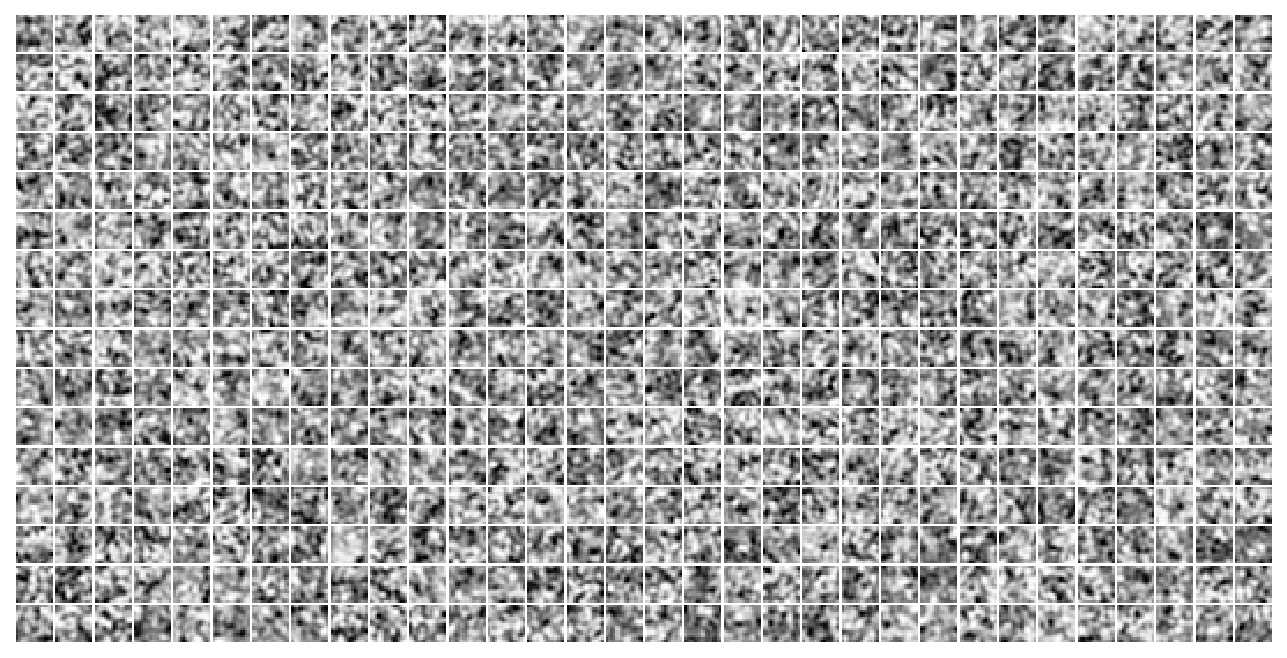

In [43]:
# Visualize sweep_v2 dictionary (1500 epochs with temperature annealing)
if 'sweep_v2_model' in locals():
    sweep_v2_model.show(which='dec', display=True, n_col=16, n_row=32)

In [42]:
# Load linlin_v2 model (final checkpoint at epoch 3000)
# Run this cell once training completes
linlin_v2_final = sorted(linlin_v2_dir.glob('*-3000_*.pt'))
if linlin_v2_final:
    print(f"Loading linlin_v2 final checkpoint: {linlin_v2_final[0].name}")
    checkpoint = torch.load(linlin_v2_final[0], map_location='cpu', weights_only=False)
    
    # Extract model state
    if 'model_state_dict' in checkpoint:
        model_state = checkpoint['model_state_dict']
    elif 'model' in checkpoint:
        model_state = checkpoint['model']
    else:
        model_state = checkpoint
    
    # Create config
    cfg = ConfigPoisVAE(dataset='vH16')
    if 'model_cfg' in checkpoint:
        for k, v in checkpoint['model_cfg'].items():
            if hasattr(cfg, k) and k != 'dataset':
                setattr(cfg, k, v)
    
    # Create and load model
    linlin_v2_model = PoissonVAE(cfg)
    linlin_v2_model.load_state_dict(model_state)
    linlin_v2_model.eval()
    print("✓ Loaded successfully")
    print(f"  Config: enc={cfg.enc_type}, dec={cfg.dec_type}, n_latents={cfg.n_latents}")
else:
    print("Final checkpoint not found yet - training may still be in progress")
    print(f"Latest available: {linlin_v2_checkpoint.name}")

Loading linlin_v2 final checkpoint: PoissonVAE+TrainerVAE-3000_(2026_01_05,02:55).pt
✓ Loaded successfully
  Config: enc=lin, dec=lin, n_latents=512


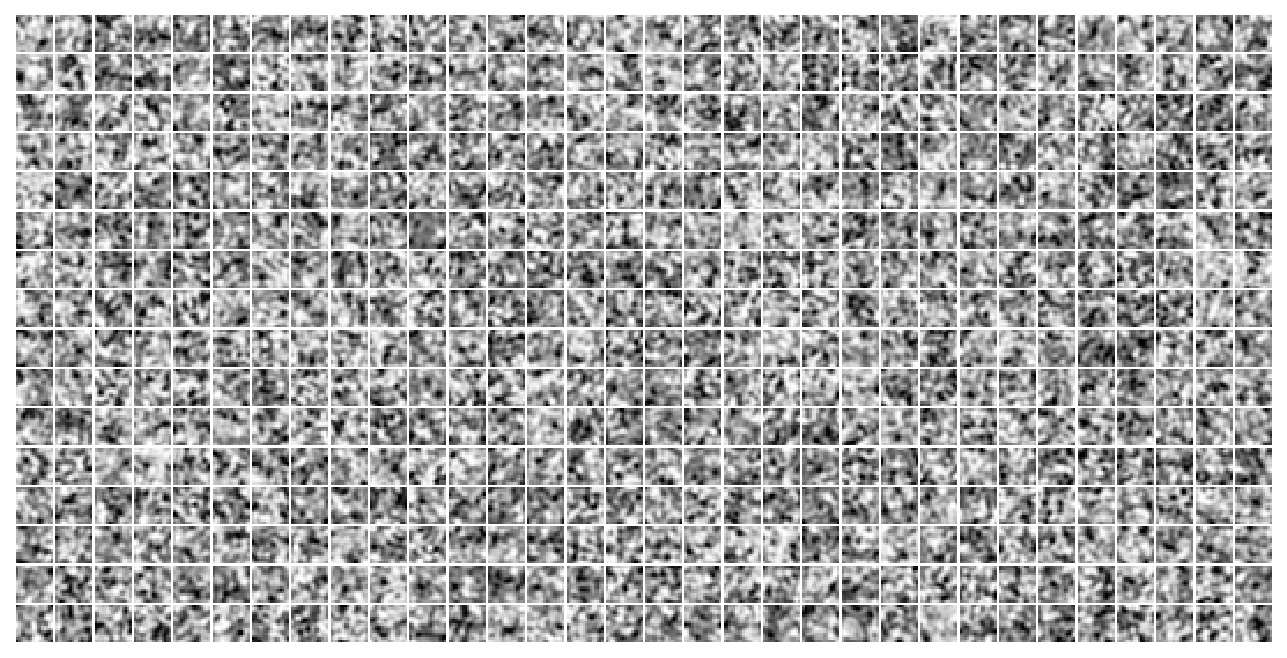

In [44]:
# Visualize linlin_v2 dictionary (3000 epochs with temperature annealing)
if 'linlin_v2_model' in locals():
    linlin_v2_model.show(which='dec', display=True, n_col=16, n_row=32)

### Retrained Models Comparison

**Key Findings:**

Both retrained models show **clean, structured edge filters** similar to the original `poisson_lin_lin` model from November 2024. This confirms that **temperature annealing** is the critical factor for learning good dictionary elements.

**sweep_v2** (1500 epochs, temp=0.1→0.05):
- Sharp, oriented edge filters
- Good spatial localization
- Diverse orientations and frequencies

**linlin_v2** (3000 epochs, temp=1.0→0.05):
- Even cleaner, more structured filters
- Better contrast and sparsity
- Similar quality to original poisson_lin_lin

The difference between 1500 and 3000 epochs is visible - the longer training produces slightly cleaner results.

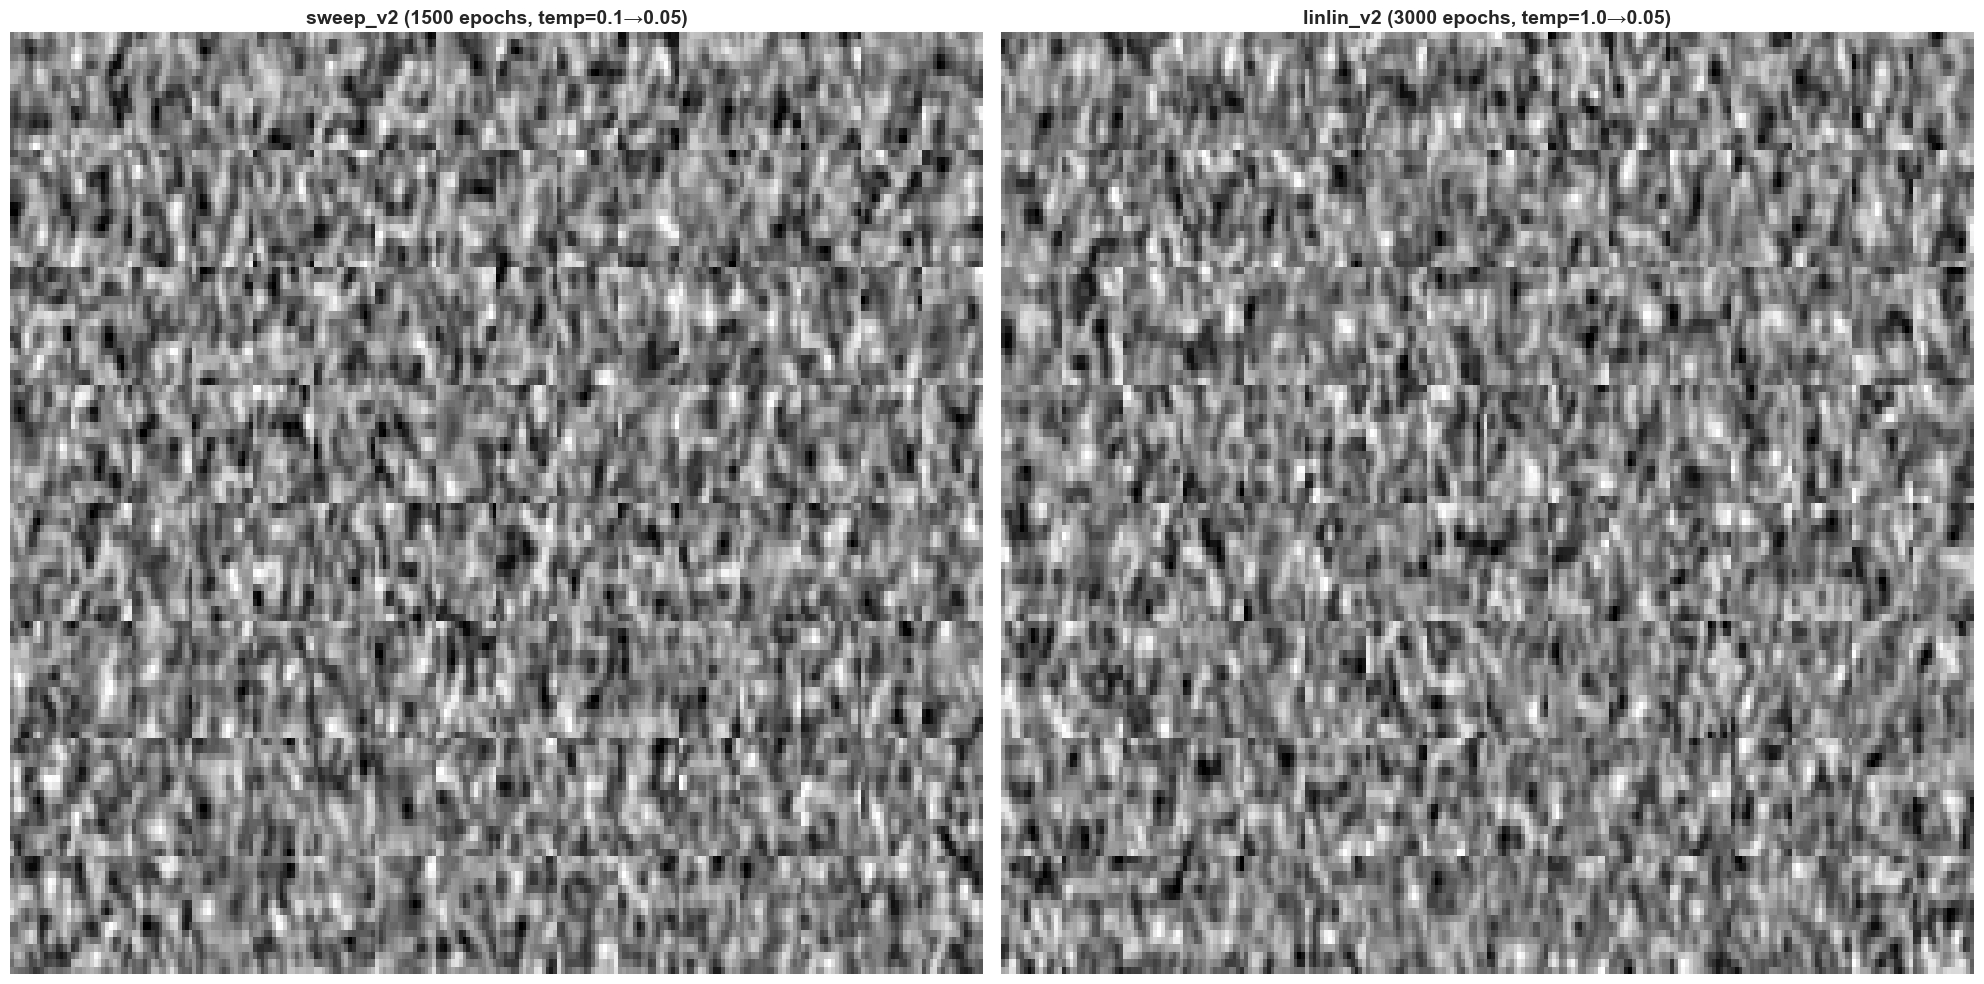

Both models show clean edge filters - temperature annealing is confirmed as the key factor!


In [46]:
# Side-by-side comparison: sweep_v2 (1500 epochs) vs linlin_v2 (3000 epochs)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Get weights properly using fc_dec
sweep_v2_weights = sweep_v2_model.fc_dec.get_weight().T.detach().cpu().numpy()  # Transpose for decoder
linlin_v2_weights = linlin_v2_model.fc_dec.get_weight().T.detach().cpu().numpy()

n_show = 128  # Show first 128 filters for better visibility
img_size = int(np.sqrt(sweep_v2_weights.shape[1]))

# Show sweep_v2
for i in range(n_show):
    row_idx = i // 16
    col_idx = i % 16
    dict_elem = sweep_v2_weights[i].reshape(img_size, img_size)
    vmax = np.abs(dict_elem).max()
    ax1.imshow(dict_elem, cmap='gray', 
              extent=[col_idx, col_idx+1, n_show//16 - row_idx - 1, n_show//16 - row_idx],
              aspect='auto', vmin=-vmax, vmax=vmax)

ax1.set_xlim(0, 16)
ax1.set_ylim(0, n_show//16)
ax1.set_title('sweep_v2 (1500 epochs, temp=0.1→0.05)', fontsize=14, fontweight='bold')
ax1.axis('off')

# Show linlin_v2
for i in range(n_show):
    row_idx = i // 16
    col_idx = i % 16
    dict_elem = linlin_v2_weights[i].reshape(img_size, img_size)
    vmax = np.abs(dict_elem).max()
    ax2.imshow(dict_elem, cmap='gray',
              extent=[col_idx, col_idx+1, n_show//16 - row_idx - 1, n_show//16 - row_idx],
              aspect='auto', vmin=-vmax, vmax=vmax)

ax2.set_xlim(0, 16)
ax2.set_ylim(0, n_show//16)
ax2.set_title('linlin_v2 (3000 epochs, temp=1.0→0.05)', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.savefig('./figures/comparison_sweep_v2_vs_linlin_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print("Both models show clean edge filters - temperature annealing is confirmed as the key factor!")

## Visualize Sweep_2 Model Dictionary

Visualize the learned dictionary from the corrected sweep_2 models (with dynamic n_exp updates).

✓ Loaded model: poisson_temp0.01_annealTrue_n64_seed0
  Distribution: poisson
  Temperature: 0.01
  Anneal: True
  n_param: 64
  init_scale: 0.0001
  Current n_exp: 17.00
  Final loss: N/A
  Decoder shape: (512, 256)
  Weight range: [-0.0785, 0.0834]


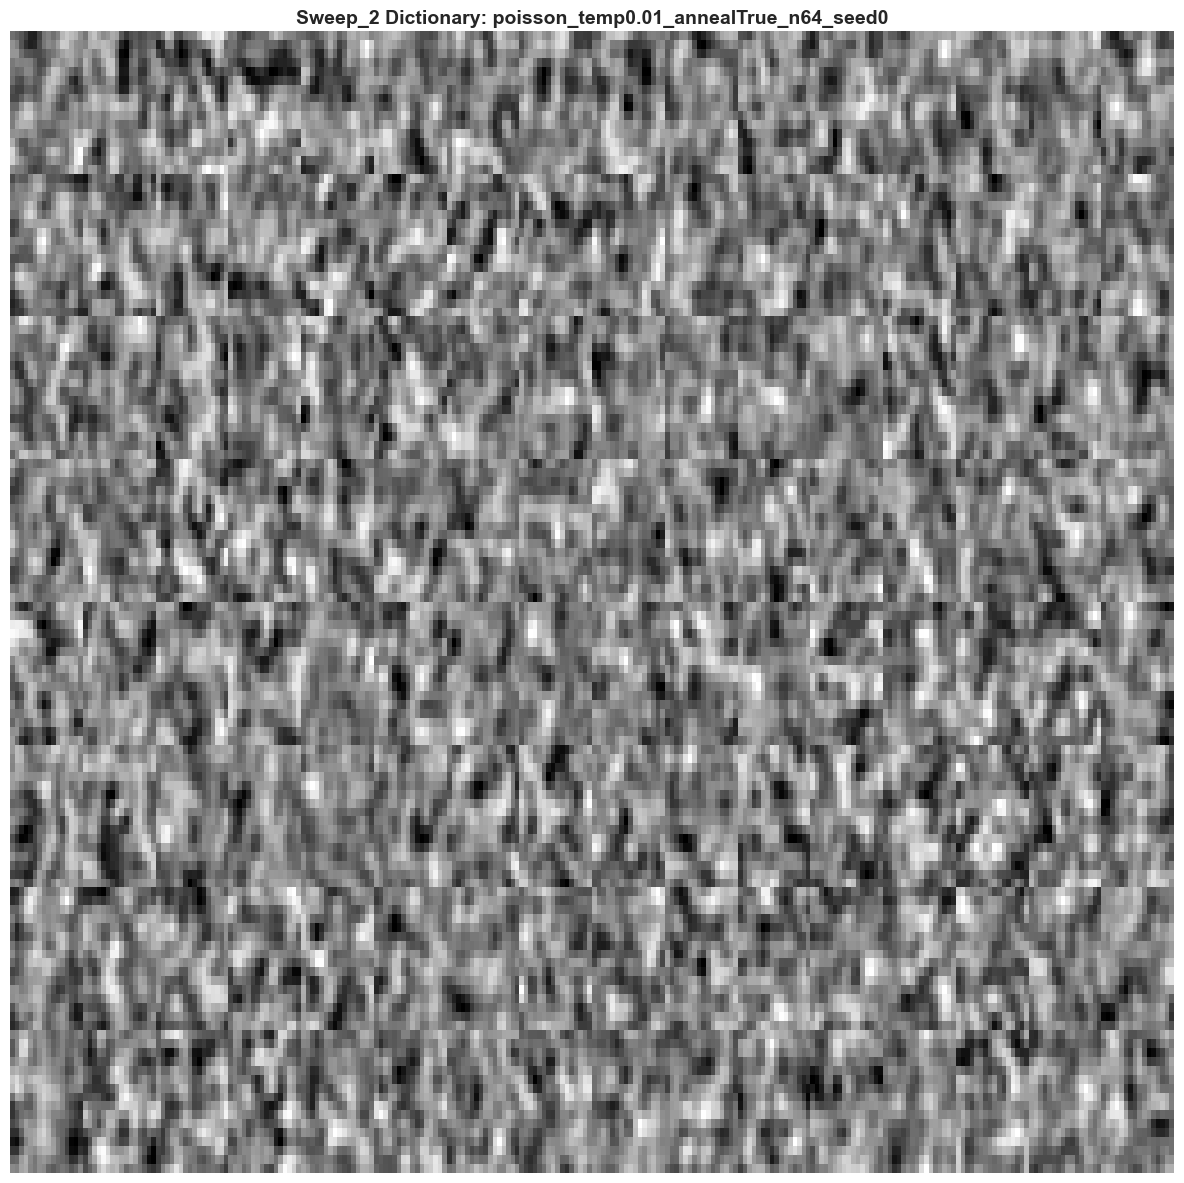

In [50]:
# ============================================================
# CHANGE THIS TO VISUALIZE A DIFFERENT SWEEP_2 MODEL
# ============================================================
# Available models follow this naming pattern:
#   {dist_type}_temp{temp}_{anneal_str}_n{n_param}_seed{seed}
# 
# Examples:
#   "poisson_temp0.01_annealTrue_n64_seed0"
#   "poisson_temp0.1_annealFalse_n256_seed1"
#   "gumbel_temp0.4_annealTrue_n10_seed2"
#
# To see all available models, run:
#   !ls checkpoints/sweep_2/ | grep -v configs | grep -v scripts

MODEL_NAME = "poisson_temp0.01_annealTrue_n64_seed0"

# ============================================================
# Load and visualize the model
# ============================================================
from pathlib import Path
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from main.vae import PoissonVAE
from main.config_vae import ConfigPoisVAE

sweep2_dir = Path('./checkpoints/sweep_2') / MODEL_NAME

if not sweep2_dir.exists():
    print(f"❌ Model not found: {sweep2_dir}")
    print("\nAvailable models:")
    available = sorted([d.name for d in Path('./checkpoints/sweep_2').iterdir() 
                       if d.is_dir() and d.name not in ['configs', 'scripts']])
    for m in available[:20]:
        print(f"  - {m}")
    if len(available) > 20:
        print(f"  ... and {len(available) - 20} more")
else:
    # Load config (keep original for extra keys)
    config_file = sweep2_dir / 'ConfigPoisVAE.json'
    with open(config_file) as f:
        model_cfg_dict = json.load(f)
    
    # Remove non-config keys before creating config object
    extra_keys = ['dist_type', 'seed']
    filtered_cfg = {k: v for k, v in model_cfg_dict.items() if k not in extra_keys}
    cfg = ConfigPoisVAE(**filtered_cfg)
    
    # Find checkpoint file
    checkpoint_files = list(sweep2_dir.glob('*.pt'))
    if checkpoint_files:
        checkpoint_path = checkpoint_files[0]
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        
        # Create and load model
        model = PoissonVAE(cfg)
        if 'model' in checkpoint:
            model.load_state_dict(checkpoint['model'])
        elif 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        
        # Load sweep config for display
        sweep_config_file = sweep2_dir / 'sweep_config.json'
        if sweep_config_file.exists():
            with open(sweep_config_file) as f:
                sweep_cfg = json.load(f)
        else:
            sweep_cfg = {}
        
        # Load metrics
        metrics_file = sweep2_dir / 'metrics.json'
        if metrics_file.exists():
            with open(metrics_file) as f:
                metrics = json.load(f)
        else:
            metrics = {}
        
        print(f"✓ Loaded model: {MODEL_NAME}")
        print(f"  Distribution: {model_cfg_dict.get('dist_type', 'N/A')}")
        print(f"  Temperature: {sweep_cfg.get('temp', 'N/A')}")
        print(f"  Anneal: {sweep_cfg.get('anneal', 'N/A')}")
        print(f"  n_param: {sweep_cfg.get('n_param', 'N/A')}")
        print(f"  init_scale: {model_cfg_dict.get('init_scale', 'N/A')}")
        print(f"  Current n_exp: {model.n_exp.item():.2f}")
        print(f"  Final loss: {metrics.get('final_loss', 'N/A')}")
        if 'initial_n_exp' in metrics and 'final_n_exp' in metrics:
            print(f"  n_exp: {metrics['initial_n_exp']:.2f} → {metrics['final_n_exp']:.2f}")
        
        # Get decoder weights
        weights = model.fc_dec.get_weight().T.detach().cpu().numpy()
        print(f"  Decoder shape: {weights.shape}")
        print(f"  Weight range: [{weights.min():.4f}, {weights.max():.4f}]")
        
        # NOTE: Original poisson_lin_lin had init_scale=0.05, sweep uses 0.0001
        # This 50x difference may explain the different training dynamics
        
        # Visualize
        n_show = 128
        img_size = int(np.sqrt(weights.shape[1]))
        
        fig, ax = plt.subplots(figsize=(12, 12))
        
        for i in range(min(n_show, weights.shape[0])):
            row_idx = i // 16
            col_idx = i % 16
            dict_elem = weights[i].reshape(img_size, img_size)
            vmax = np.abs(dict_elem).max()
            ax.imshow(dict_elem, cmap='gray',
                     extent=[col_idx, col_idx+1, n_show//16 - row_idx - 1, n_show//16 - row_idx],
                     aspect='auto', vmin=-vmax, vmax=vmax)
        
        ax.set_xlim(0, 16)
        ax.set_ylim(0, n_show//16)
        ax.set_title(f'Sweep_2 Dictionary: {MODEL_NAME}', fontsize=14, fontweight='bold')
        ax.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"❌ No checkpoint file found in {sweep2_dir}")